# Notebook 1: Feature Analysis Deteksi Anomali Iklim Indoor Greenhouse (Dindigul)

Dataset: `dindigul_greenhouse_indoor_2024_dirty.csv` (data latih) dan `dindigul_greenhouse_indoor_2025_dirty.csv` (data evaluasi). Satu baris per jam, 9 kolom sensor, versi dirty.

Urutan kerja: Tahap 1 kenalan dengan data, Tahap 2 analisis untuk anomaly detection, Tahap 3 investigasi masalah data, Tahap 4 pembersihan, Tahap 5 data bersih dan penyimpanan, Tahap 6 split dan kebocoran data, Tahap 7 window, anomali sintetis, fitur statistik, Tahap 8 scaling dan encoding.

Hasil pembersihan disimpan ke `datasets/clean/` (CSV) supaya Notebook 2 dan 3 bisa memuatnya langsung tanpa mengulang pembersihan.

# Persiapan

In [13]:
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/greenhouse-anomaly-edgeai-main'
except ImportError:
    BASE_PATH = os.environ.get('GH_BASE', '.')      # dijalankan di luar Colab
print('BASE_PATH:', BASE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_PATH: /content/drive/MyDrive/greenhouse-anomaly-edgeai-main


In [14]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from os.path import join
from scipy import stats
from sklearn.preprocessing import (MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler,
                                   Normalizer, OneHotEncoder)
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore', category=RuntimeWarning)   # kurtosis/skew pada sinyal konstan -> NaN (ditangani manual)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 100})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
%matplotlib inline

In [15]:
# Semua angka keputusan ada di sini. Ubah di sini, seluruh notebook ikut berubah.
dataset_path = f'{BASE_PATH}/datasets'
models_path  = f'{BASE_PATH}/models'
file_2024 = 'dindigul_greenhouse_indoor_2024_dirty.csv'
file_2025 = 'dindigul_greenhouse_indoor_2025_dirty.csv'

# Urutan RAW_FEATURES menentukan urutan kanal pada window (sama dengan Notebook 2)
RAW_FEATURES = ['indoor_temp', 'indoor_humidity', 'indoor_air_velocity', 'indoor_CO2',
                'solarradiation', 'vpd', 'dew_point', 'leaf_wetness_proxy', 'day_night_flag']
CONTINUOUS = ['indoor_temp', 'indoor_humidity', 'indoor_air_velocity', 'indoor_CO2', 'solarradiation', 'dew_point']
BINARY     = ['leaf_wetness_proxy', 'day_night_flag']
NUM        = CONTINUOUS + ['vpd']

# Rentang fisik yang masuk akal untuk greenhouse tropis (di luar ini = error sensor)
VALID_RANGE = {'indoor_temp': (0, 60), 'indoor_humidity': (0, 100), 'indoor_air_velocity': (0, 15),
               'indoor_CO2': (250, 2000), 'solarradiation': (0, 1500), 'vpd': (0, 10), 'dew_point': (-10, 45)}

# Aturan pembersihan
DROP_MISSING_FRAC = 0.40    # kolom dengan data tak valid > 40 % dibuang
INTERP_LIMIT_H    = 6       # lubang <= 6 jam dianggap pendek
REDUNDANCY_R2     = 0.99    # fitur dibuang bila R2 rekonstruksi dari fitur lain >= ini

# Window dan split
window_length_hours = 24
hop_hours           = 1
block_hours         = 168   # 7 hari
CLEAN_DIR           = f'{dataset_path}/clean'   # tempat data bersih disimpan (permanen)
val_ratio, test_ratio = 0.15, 0.15
SEED = 42

COLORS = {'2024': 'tab:blue', '2025': 'tab:orange'}

# TAHAP 1: Kenalan dengan data

## 1.1 Ukuran data, contoh baris, dan tipe data

In [16]:
raw = {y: pd.read_csv(join(dataset_path, f)) for y, f in (('2024', file_2024), ('2025', file_2025))}
for y, d in raw.items():
    print(f'Tahun {y}: {d.shape[0]} baris, {d.shape[1]} kolom')
print('\nTipe data:')
print(raw['2024'].dtypes)
raw['2024'].head()

Tahun 2024: 8782 baris, 10 kolom
Tahun 2025: 8758 baris, 10 kolom

Tipe data:
datetime                object
indoor_temp            float64
indoor_humidity        float64
indoor_air_velocity    float64
indoor_CO2             float64
solarradiation         float64
day_night_flag         float64
vpd                    float64
dew_point              float64
leaf_wetness_proxy     float64
dtype: object


,datetime,indoor_temp,indoor_humidity,indoor_air_velocity,indoor_CO2,solarradiation,day_night_flag,vpd,dew_point,leaf_wetness_proxy
0,2024-01-01 00:00:00,25.002223,83.729629,1.84,440.0,0.0,0.0,0.515477,21.748148,0.0
1,2024-01-01 01:00:00,25.301924,83.230127,1.84,440.0,0.0,0.0,0.540861,21.947949,0.0
2,2024-01-01 02:00:00,24.278680,77.835534,1.84,400.0,0.0,1.0,0.672513,19.845786,0.0
3,2024-01-01 03:00:00,24.900000,76.800000,1.84,400.0,0.0,1.0,0.730558,20.260000,0.0
4,2024-01-01 04:00:00,25.623543,75.594095,1.84,400.0,0.0,1.0,0.802309,20.742362,0.0


`datetime` masih berupa teks, diubah ke tipe datetime supaya bisa dipakai untuk analisis waktu.

In [17]:
for y in raw:
    raw[y]['datetime'] = pd.to_datetime(raw[y]['datetime'])
print(raw['2024'].dtypes)

datetime               datetime64[ns]
indoor_temp                   float64
indoor_humidity               float64
indoor_air_velocity           float64
indoor_CO2                    float64
solarradiation                float64
day_night_flag                float64
vpd                           float64
dew_point                     float64
leaf_wetness_proxy            float64
dtype: object


## 1.2 Missing value

2024                  2025           
                    jumlah_NaN persen_NaN jumlah_NaN persen_NaN
datetime                     0       0.00          0       0.00
indoor_temp                141       1.61        141       1.61
indoor_humidity            153       1.74        153       1.75
indoor_air_velocity       4030      45.89       3948      45.08
indoor_CO2                 387       4.41        386       4.41
solarradiation             178       2.03        178       2.03
day_night_flag              86       0.98         87       0.99
vpd                         87       0.99         87       0.99
dew_point                   87       0.99         87       0.99
leaf_wetness_proxy          87       0.99         87       0.99


2024: baris dengan minimal 1 NaN = 4633 (52.8%) | semua sensor NaN = 0
Distribusi jumlah NaN per baris: {0: 4149, 1: 4061, 2: 542, 3: 29, 4: 1}

2025: baris dengan minimal 1 NaN = 4597 (52.5%) | semua sensor NaN = 0
Distribusi jumlah NaN per baris: {0: 4161, 1: 4070, 2: 497, 3: 30}


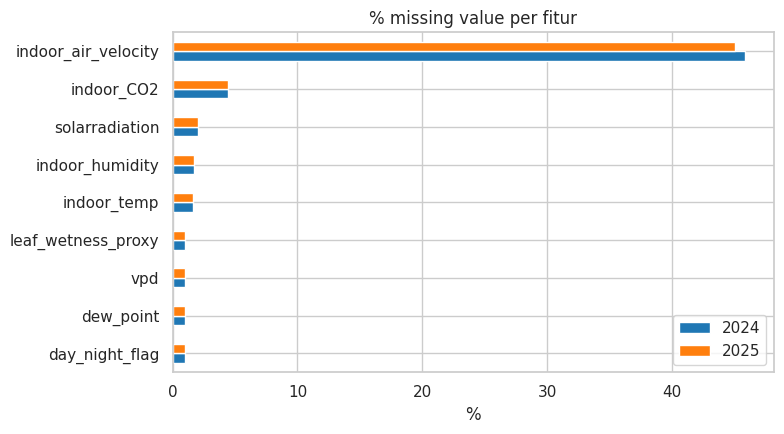

In [18]:
miss = pd.concat({y: pd.DataFrame({'jumlah_NaN': d.isna().sum(), 'persen_NaN': (d.isna().mean() * 100).round(2)})
                  for y, d in raw.items()}, axis=1)
display(miss)

for y, d in raw.items():
    n_nan_row = d[RAW_FEATURES].isna().sum(axis=1)
    print(f'\n{y}: baris dengan minimal 1 NaN = {(n_nan_row > 0).sum()} ({(n_nan_row > 0).mean():.1%}) | semua sensor NaN = {(n_nan_row == len(RAW_FEATURES)).sum()}')
    print('Distribusi jumlah NaN per baris:', n_nan_row.value_counts().sort_index().to_dict())

pers = pd.DataFrame({y: raw[y][RAW_FEATURES].isna().mean() * 100 for y in raw})
ax = pers.sort_values('2024').plot.barh(figsize=(8, 4.5), color=[COLORS['2024'], COLORS['2025']])
ax.set_xlabel('%'); ax.set_title('% missing value per fitur')
plt.tight_layout(); plt.show()

Temuan: `indoor_air_velocity` kosong sekitar 45 % di kedua tahun, kolom lain hanya 1 sampai 4,5 %. Sekitar 52 % baris punya minimal satu NaN, jadi membuang baris yang bolong akan menghilangkan separuh data. Pilihannya imputasi atau membuang kolom.

## 1.3 Statistik ringkas

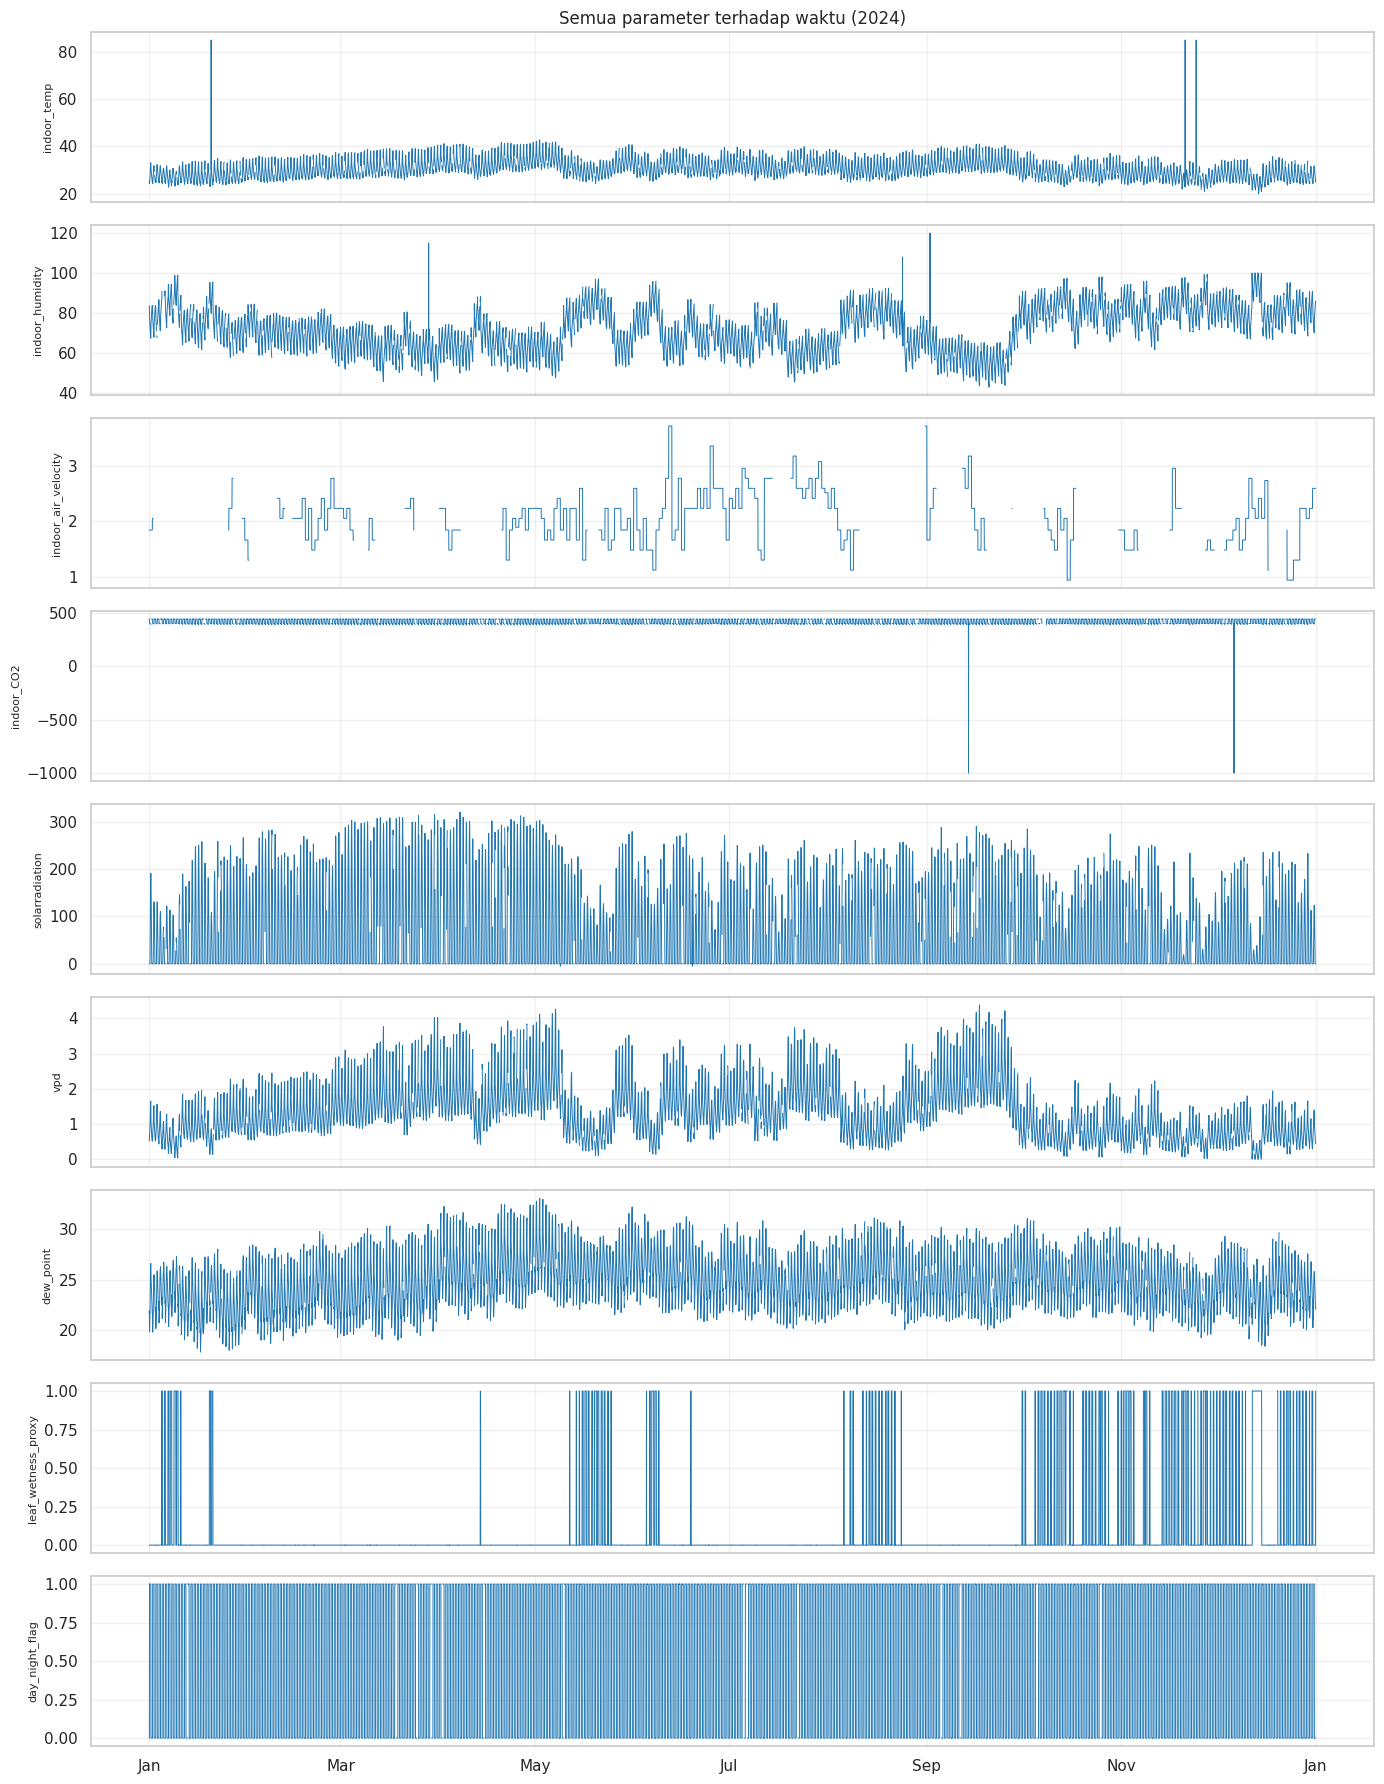

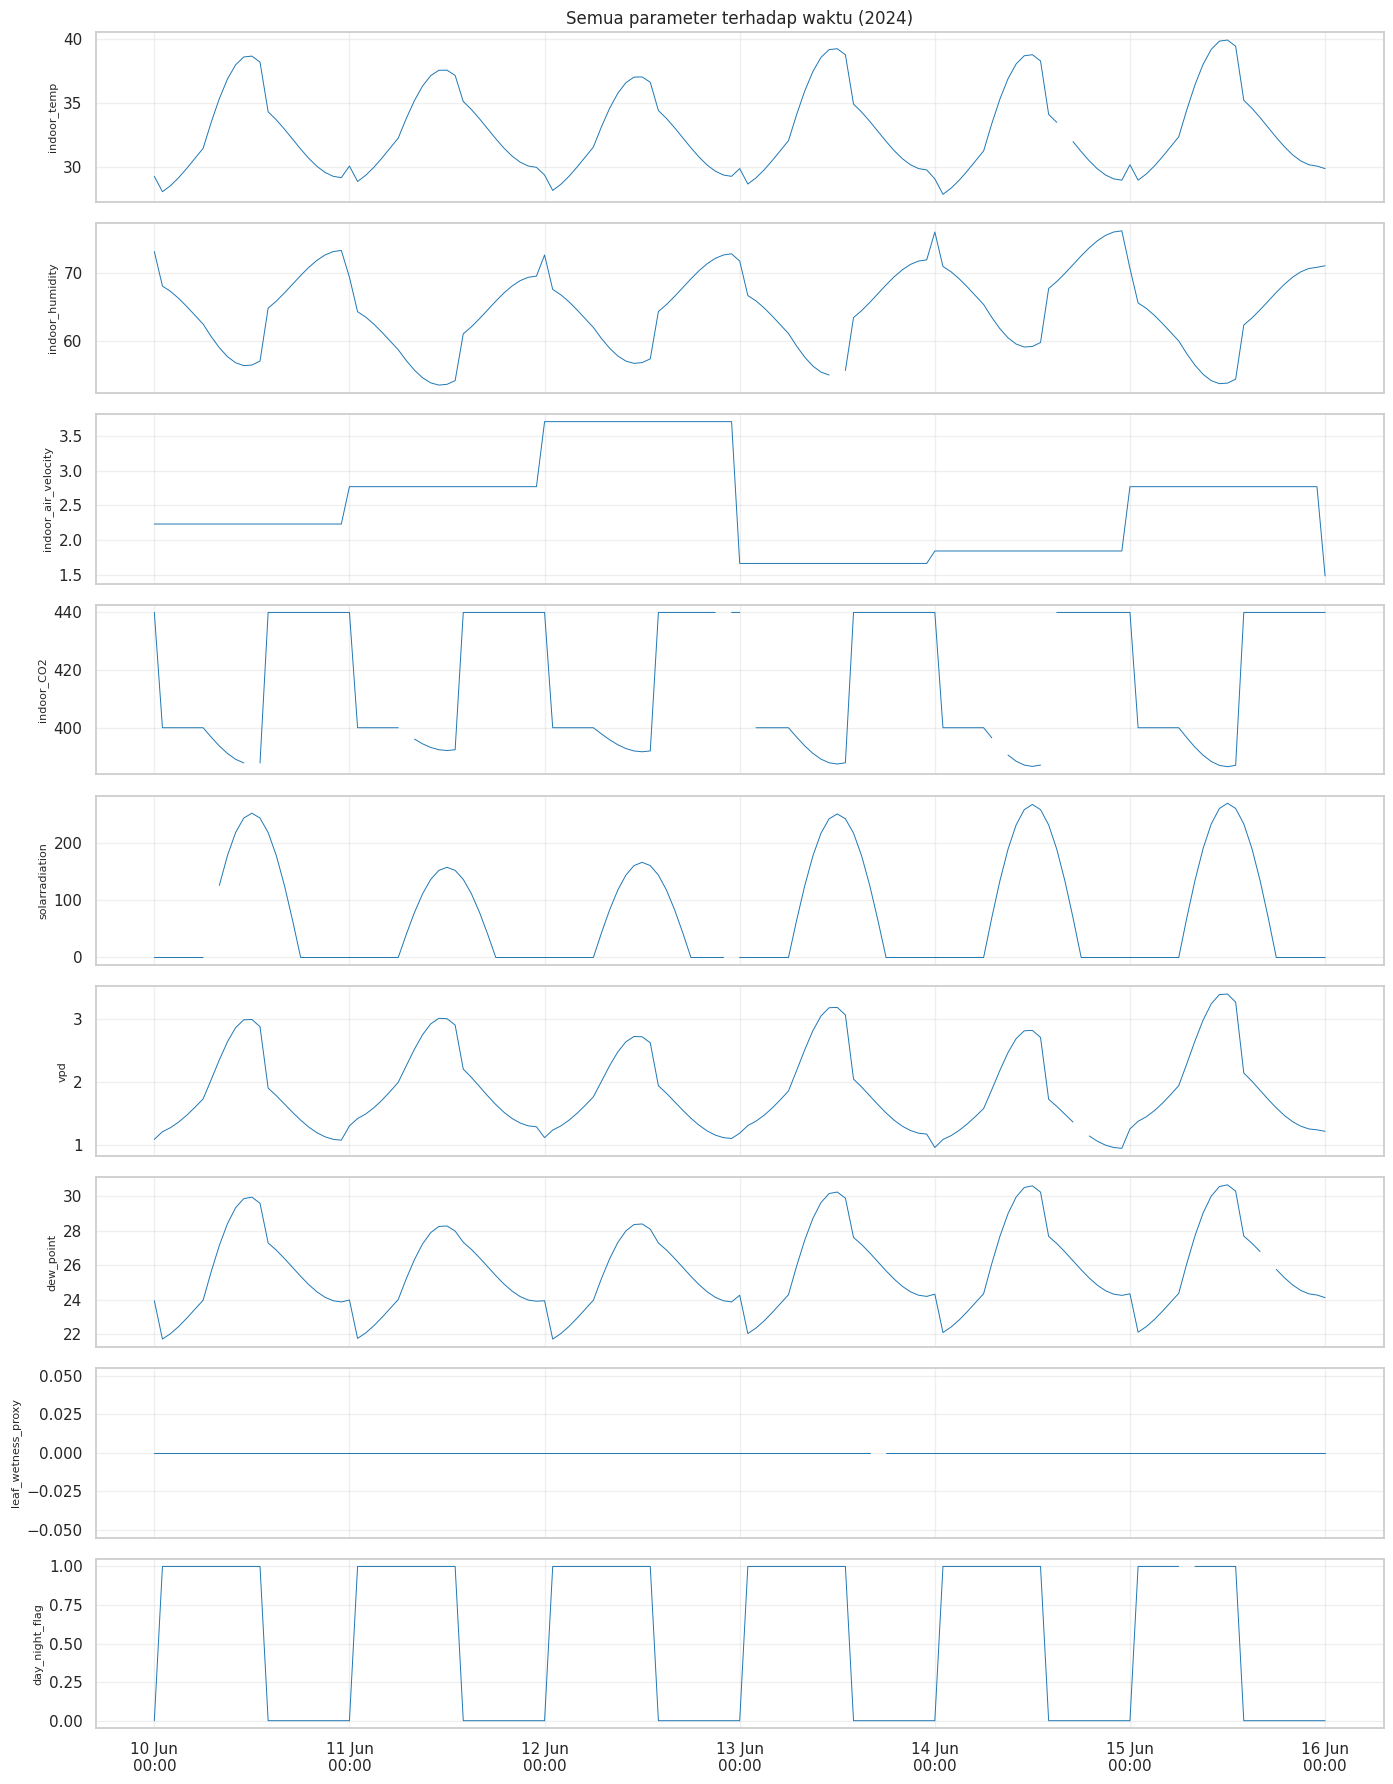

In [19]:
def plot_semua_parameter(tahun, start=None, end=None, fmt='%b'):
    d = raw[tahun]
    if start is not None: d = d[d['datetime'] >= pd.Timestamp(start)]
    if end is not None:   d = d[d['datetime'] <= pd.Timestamp(end)]
    fig, axes = plt.subplots(len(RAW_FEATURES), 1, figsize=(14, 2.0 * len(RAW_FEATURES)), sharex=True)
    for ax, c in zip(axes, RAW_FEATURES):
        ax.plot(d['datetime'], d[c], lw=.7, color=COLORS[tahun])
        ax.set_ylabel(c, fontsize=8); ax.grid(alpha=.3)
    axes[0].set_title(f'Semua parameter terhadap waktu ({tahun})')
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter(fmt))
    plt.tight_layout(); plt.show()

plot_semua_parameter('2024')                                                       # seluruh tahun
plot_semua_parameter('2024', '2024-06-10', '2024-06-16', fmt='%d %b\n%H:%M')       # zoom satu minggu

In [20]:
for y, d in raw.items():
    print(f'===== {y}')
    display(d[RAW_FEATURES].describe().T.round(2))

===== 2024


,count,mean,std,min,25%,50%,75%,max
indoor_temp,8641.0,30.56,3.95,19.80,27.70,30.10,33.00,85.00
indoor_humidity,8629.0,71.84,10.97,43.04,63.70,71.53,80.03,120.00
indoor_air_velocity,4752.0,2.08,0.48,0.94,1.66,2.05,2.41,3.71
indoor_CO2,8395.0,417.48,31.21,-999.00,397.80,400.00,440.00,440.00
solarradiation,8604.0,67.55,88.34,-5.00,0.00,0.00,134.90,320.20
vpd,8695.0,1.34,0.78,0.00,0.76,1.22,1.74,4.38
dew_point,8695.0,24.90,2.57,17.85,23.04,24.72,26.69,33.12
leaf_wetness_proxy,8695.0,0.10,0.30,0.00,0.00,0.00,0.00,1.00
day_night_flag,8696.0,0.50,0.50,0.00,0.00,1.00,1.00,1.00


===== 2025


,count,mean,std,min,25%,50%,75%,max
indoor_temp,8617.0,30.25,4.04,18.40,27.50,29.90,32.71,85.00
indoor_humidity,8605.0,69.50,10.91,38.32,61.90,69.54,77.07,120.00
indoor_air_velocity,4810.0,2.13,0.53,0.76,1.84,2.05,2.41,3.89
indoor_CO2,8372.0,417.55,31.27,-999.00,397.80,400.00,440.00,440.00
solarradiation,8580.0,68.22,89.08,-5.00,0.00,0.00,134.99,322.80
vpd,8671.0,1.42,0.78,0.00,0.84,1.28,1.84,4.76
dew_point,8671.0,24.12,2.75,15.51,22.22,23.96,25.97,32.29
leaf_wetness_proxy,8671.0,0.06,0.23,0.00,0.00,0.00,0.00,1.00
day_night_flag,8671.0,0.50,0.50,0.00,0.00,1.00,1.00,1.00


## 1.4 Baris duplikat

In [21]:
for y, d in raw.items():
    print(f'{y} | duplikat seluruh kolom: {d.duplicated().sum()} | duplikat datetime: {d["datetime"].duplicated().sum()}')
display(raw['2024'][raw['2024']['datetime'].duplicated(keep=False)])

2024 | duplikat seluruh kolom: 4 | duplikat datetime: 4
2025 | duplikat seluruh kolom: 4 | duplikat datetime: 4


,datetime,indoor_temp,indoor_humidity,indoor_air_velocity,indoor_CO2,solarradiation,day_night_flag,vpd,dew_point,leaf_wetness_proxy
5566,2024-08-19 22:00:00,26.602223,92.329629,NaN,440.000,0.000000,0.0,0.267157,25.068148,1.0
5567,2024-08-19 22:00:00,26.602223,92.329629,NaN,440.000,0.000000,0.0,0.267157,25.068148,1.0
5874,2024-09-01 17:00:00,31.400000,70.900000,1.66,440.000,49.952076,0.0,1.337412,25.580000,0.0
5875,2024-09-01 17:00:00,31.400000,70.900000,1.66,440.000,49.952076,0.0,1.337412,25.580000,0.0
7714,2024-11-17 08:00:00,30.171320,79.289466,2.95,394.625,107.500000,1.0,0.887434,26.029214,0.0
7715,2024-11-17 08:00:00,30.171320,79.289466,2.95,394.625,107.500000,1.0,0.887434,26.029214,0.0
8365,2024-12-14 16:00:00,24.676457,94.505905,2.41,NaN,49.600000,0.0,0.170715,23.577638,1.0
8366,2024-12-14 16:00:00,24.676457,94.505905,2.41,NaN,49.600000,0.0,0.170715,23.577638,1.0


# TAHAP 2: Hal yang spesifik untuk anomaly detection

## 2.1 Rentang dan interval waktu

===== 2024
Mulai   : 2024-01-01 00:00:00
Selesai : 2024-12-31 23:00:00
Durasi  : 365 days 23:00:00
Urut menurut waktu?: True
Interval antar baris (jam) -> jumlah: {0.0: 4, 1.0: 8776, 7.0: 1}
Jam yang seharusnya ada: 8784 | baris: 8782 | timestamp unik: 8778 | jam hilang: 6
Gap 7 jam: 2024-12-05 04:00:00 -> 2024-12-05 11:00:00
===== 2025
Mulai   : 2025-01-01 00:00:00
Selesai : 2025-12-31 23:00:00
Durasi  : 364 days 23:00:00
Urut menurut waktu?: True
Interval antar baris (jam) -> jumlah: {0.0: 4, 1.0: 8752, 7.0: 1}
Jam yang seharusnya ada: 8760 | baris: 8758 | timestamp unik: 8754 | jam hilang: 6
Gap 7 jam: 2025-07-24 12:00:00 -> 2025-07-24 19:00:00


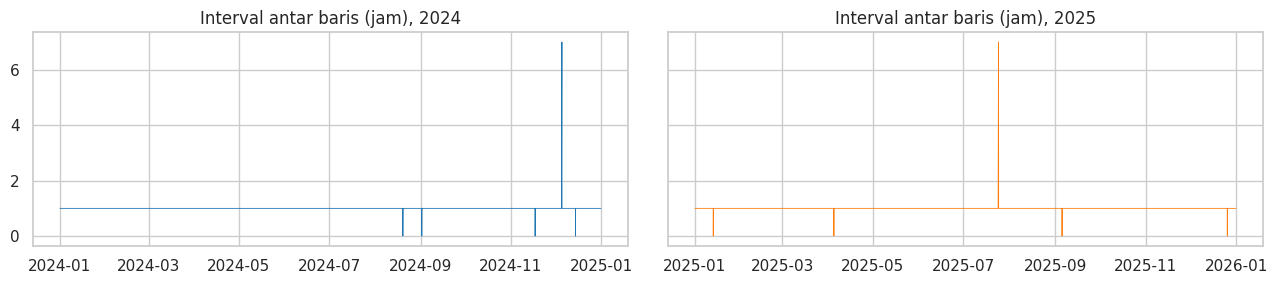

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3), sharey=True)
for ax, (y, d) in zip(axes, raw.items()):
    t = d['datetime']; gap = t.diff().dt.total_seconds() / 3600
    expected = int((t.max() - t.min()) / pd.Timedelta(hours=1)) + 1
    print(f'===== {y}')
    print('Mulai   :', t.min()); print('Selesai :', t.max()); print('Durasi  :', t.max() - t.min())
    print('Urut menurut waktu?:', t.is_monotonic_increasing)
    print('Interval antar baris (jam) -> jumlah:', gap.value_counts().sort_index().to_dict())
    print(f'Jam yang seharusnya ada: {expected} | baris: {len(d)} | timestamp unik: {t.nunique()} | jam hilang: {expected - t.nunique()}')
    big = d.loc[gap > 1, 'datetime']
    for i in big.index:
        print(f'Gap {gap[i]:.0f} jam: {t[i - 1]} -> {t[i]}')
    ax.plot(t, gap, lw=.6, color=COLORS[y]); ax.set_title(f'Interval antar baris (jam), {y}')
plt.tight_layout(); plt.show()

Temuan: interval 1 jam konsisten. Per tahun ada 4 timestamp ganda dan 1 gap 7 jam (2024-12-05 dan 2025-07-24), sehingga 6 jam hilang per tahun. 2024 kabisat (8784 jam), 2025 8760 jam. Deret harus dilengkapi ke jam penuh sebelum dibuat window.

## 2.2 Jumlah data

,baris_2024,baris_2025,seharusnya_2024,seharusnya_2025,selisih_2024,selisih_2025
Jan,744,745,744,744,0,1
Feb,696,672,696,672,0,0
Mar,744,744,744,744,0,0
Apr,720,721,720,720,0,1
Mei,744,744,744,744,0,0
Jun,720,720,720,720,0,0
Jul,744,738,744,744,0,-6
Agu,745,744,744,744,1,0
Sep,721,721,720,720,1,1
Okt,744,744,744,744,0,0


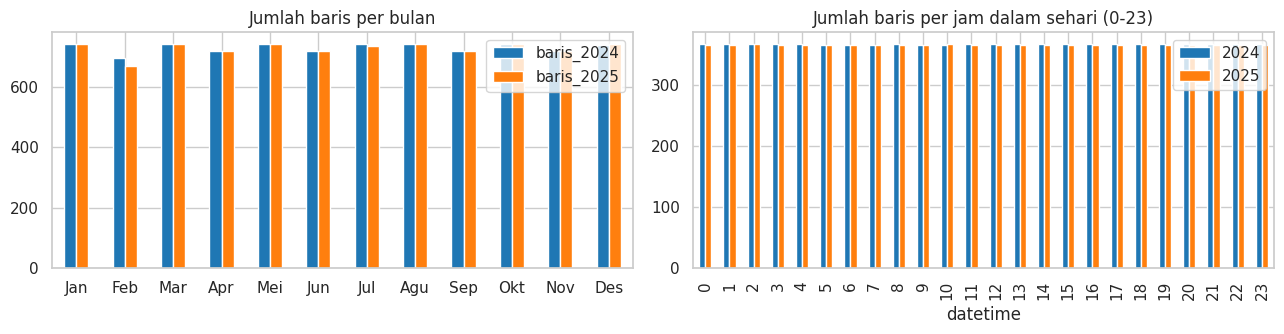

In [23]:
bulan_nama = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
cnt = pd.DataFrame({f'baris_{y}': d.groupby(d['datetime'].dt.month).size() for y, d in raw.items()})
exp = pd.DataFrame({f'seharusnya_{y}': {m: pd.Period(f'{y}-{m:02d}').days_in_month * 24 for m in range(1, 13)} for y in raw})
tab = pd.concat([cnt, exp], axis=1); tab.index = bulan_nama
tab['selisih_2024'] = tab['baris_2024'] - tab['seharusnya_2024']
tab['selisih_2025'] = tab['baris_2025'] - tab['seharusnya_2025']
display(tab)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
cnt.set_axis(bulan_nama).plot.bar(ax=ax[0], rot=0, color=[COLORS['2024'], COLORS['2025']], title='Jumlah baris per bulan')
pd.DataFrame({y: d.groupby(d['datetime'].dt.hour).size() for y, d in raw.items()}).plot.bar(
    ax=ax[1], color=[COLORS['2024'], COLORS['2025']], title='Jumlah baris per jam dalam sehari (0-23)')
plt.tight_layout(); plt.show()

## 2.3 Nilai nol, sentinel, dan nilai di luar rentang fisik

In [24]:
def invalid_mask(d):
    """True pada sel yang nilainya ADA tetapi mustahil (di luar rentang fisik, atau biner yang bukan 0/1)."""
    m = pd.DataFrame(False, index=d.index, columns=RAW_FEATURES)
    for c, (lo, hi) in VALID_RANGE.items():
        m[c] = (d[c] < lo) | (d[c] > hi)
    for c in BINARY:
        m[c] = d[c].notna() & ~d[c].isin([0, 1])
    return m

# Gabungan dua tahun untuk analisis lintas tahun. MASKALL = nilai mustahil diganti NaN.
RAWALL = pd.concat([d.assign(tahun=y) for y, d in raw.items()], ignore_index=True)
BADALL = invalid_mask(RAWALL)
MASKALL = RAWALL.copy()
MASKALL[RAW_FEATURES] = RAWALL[RAW_FEATURES].mask(BADALL)

for y in raw:
    d = RAWALL[RAWALL.tahun == y]
    z = d[RAW_FEATURES] == 0
    print(f'===== {y}')
    display(pd.DataFrame({'jumlah_nol': z.sum(), 'persen_nol': (z.mean() * 100).round(2),
                          'sentinel_-999': (d[RAW_FEATURES] == -999).sum(),
                          'di_luar_rentang_fisik': BADALL[RAWALL.tahun == y].sum()}))

v0 = RAWALL[RAWALL['vpd'] == 0]
print('Baris dengan vpd = 0 (semua tahun):', len(v0), '| RH pada baris itu: min', round(v0['indoor_humidity'].min(), 2), 'median', round(v0['indoor_humidity'].median(), 2))

===== 2024


,jumlah_nol,persen_nol,sentinel_-999,di_luar_rentang_fisik
indoor_temp,0,0.00,0,3
indoor_humidity,0,0.00,0,3
indoor_air_velocity,0,0.00,0,0
indoor_CO2,0,0.00,2,2
solarradiation,4300,48.96,0,2
vpd,14,0.16,0,0
dew_point,0,0.00,0,0
leaf_wetness_proxy,7839,89.26,0,0
day_night_flag,4314,49.12,0,0


===== 2025


,jumlah_nol,persen_nol,sentinel_-999,di_luar_rentang_fisik
indoor_temp,0,0.00,0,3
indoor_humidity,0,0.00,0,3
indoor_air_velocity,0,0.00,0,0
indoor_CO2,0,0.00,2,2
solarradiation,4299,49.09,0,2
vpd,10,0.11,0,0
dew_point,0,0.00,0,0
leaf_wetness_proxy,8170,93.29,0,0
day_night_flag,4312,49.23,0,0


Baris dengan vpd = 0 (semua tahun): 24 | RH pada baris itu: min 100.0 median 100.0


Temuan: nol pada `solarradiation` (sekitar 49 %) dan `leaf_wetness_proxy` (89 sampai 93 %) wajar karena malam hari dan kondisi kering. Sentinel -999 hanya di CO2 (2 baris per tahun). Seluruh 24 baris `vpd = 0` punya RH tepat 100 %, jadi sah. Nilai mustahil totalnya hanya 10 sel per tahun.

## 2.4 Outlier (IQR) dan batas fisik

===== 2024: IQR pada data mentah (kiri) vs setelah nilai mustahil dibuang (kanan)


mentah                                          tanpa_mustahil                                         
                    batas_bawah batas_atas jumlah_outlier persen_outlier    batas_bawah batas_atas jumlah_outlier persen_outlier
indoor_temp               19.75      40.95             47           0.54          19.75      40.95             44           0.50
indoor_humidity           39.21     104.52              3           0.03          39.24     104.46              0           0.00
indoor_air_velocity        0.53       3.54             40           0.46           0.53       3.54             40           0.46
indoor_CO2               334.51     503.29              2           0.02         334.56     503.26              0           0.00
solarradiation          -202.35     337.25              0           0.00        -202.35     337.25              0           0.00
dew_point                 17.56      32.18             23           0.26          17.56      32.18             23           0.26
vpd                       -0.73       3.23            281           3.20          -0.73       3.23            281           3.20

===== 2025: IQR pada data mentah (kiri) vs setelah nilai mustahil dibuang (kanan)


mentah                                          tanpa_mustahil                                         
                    batas_bawah batas_atas jumlah_outlier persen_outlier    batas_bawah batas_atas jumlah_outlier persen_outlier
indoor_temp               19.69      40.52             22           0.25          19.70      40.51             19           0.22
indoor_humidity           39.15      99.82             18           0.21          39.15      99.81             15           0.17
indoor_air_velocity        0.98       3.26            133           1.52           0.98       3.26            133           1.52
indoor_CO2               334.50     503.30              2           0.02         334.53     503.28              0           0.00
solarradiation          -202.48     337.47              0           0.00        -202.48     337.47              0           0.00
dew_point                 16.58      31.61             31           0.35          16.58      31.61             31           0.35
vpd                       -0.66       3.34            232           2.65          -0.66       3.34            232           2.65

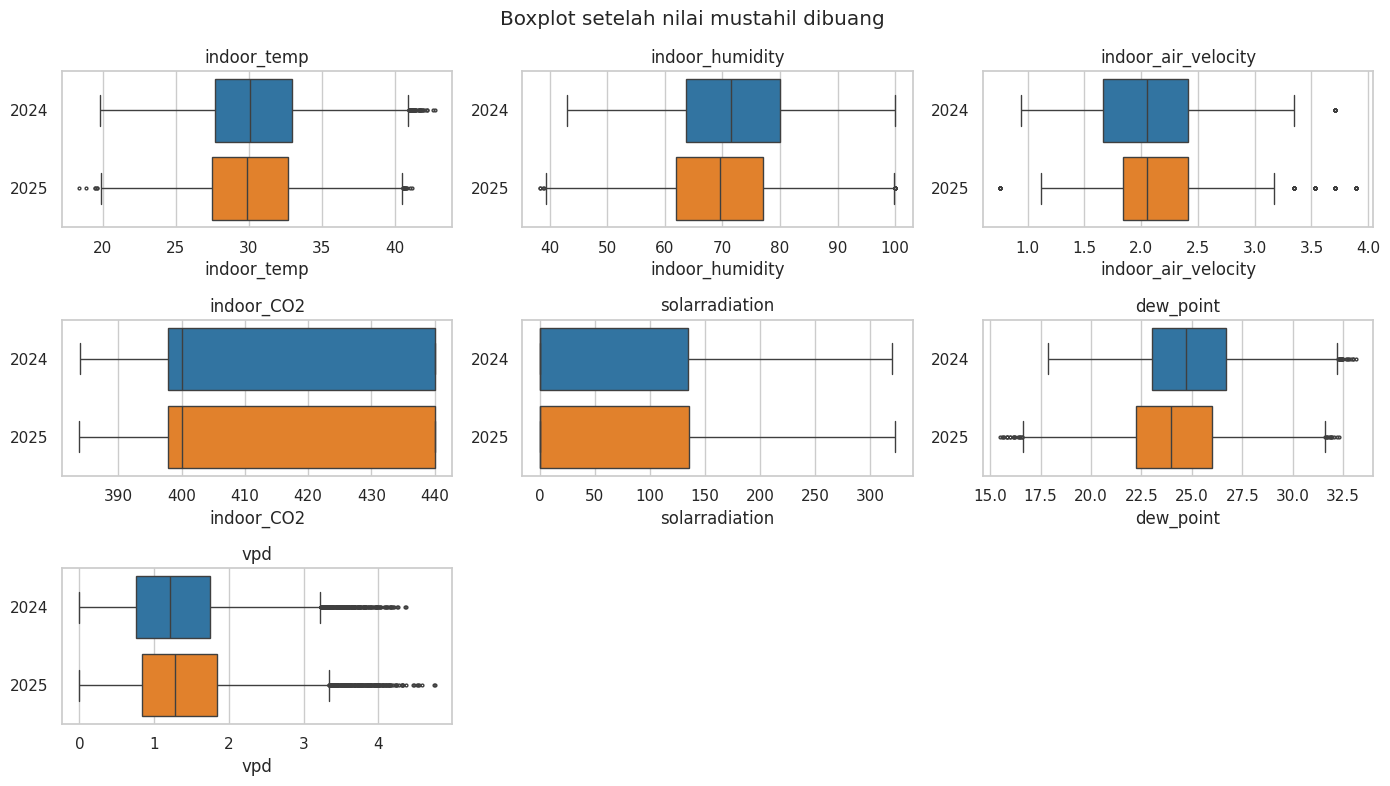

In [25]:
def iqr_table(d, cols):
    q1, q3 = d[cols].quantile(.25), d[cols].quantile(.75)
    iqr = q3 - q1; lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = (d[cols] < lo) | (d[cols] > hi)
    return pd.DataFrame({'batas_bawah': lo, 'batas_atas': hi, 'jumlah_outlier': out.sum(), 'persen_outlier': (out.mean() * 100).round(2)}).round(2)

for y in raw:
    print(f'===== {y}: IQR pada data mentah (kiri) vs setelah nilai mustahil dibuang (kanan)')
    display(pd.concat({'mentah': iqr_table(RAWALL[RAWALL.tahun == y], NUM),
                       'tanpa_mustahil': iqr_table(MASKALL[MASKALL.tahun == y], NUM)}, axis=1))

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
for ax in axes.ravel()[len(NUM):]: ax.axis('off')
for ax, c in zip(axes.ravel(), NUM):
    sns.boxplot(data=MASKALL, x=c, y='tahun', hue='tahun', palette=COLORS, orient='h', fliersize=2, legend=False, ax=ax)
    ax.set_title(c); ax.set_ylabel('')
plt.suptitle('Boxplot setelah nilai mustahil dibuang'); plt.tight_layout(); plt.show()

Temuan: `vpd` ditandai 3 % outlier IQR padahal itu bentuk distribusi miring alami (nilai tinggi di siang hari), bukan error. IQR kolom CO2 mentah rusak oleh -999. Karena itu pembuangan data memakai rentang fisik, bukan IQR.

## 2.5 Skewness

,mentah_2024,mentah_2025,tanpa_mustahil_2024,tanpa_mustahil_2025
indoor_temp,1.32,1.18,0.48,0.36
indoor_humidity,0.03,0.05,0.01,0.02
indoor_air_velocity,0.30,0.47,0.30,0.47
indoor_CO2,-22.27,-22.23,-0.06,-0.07
solarradiation,0.98,0.95,0.98,0.95
dew_point,0.27,0.12,0.27,0.12
vpd,0.97,0.97,0.97,0.97


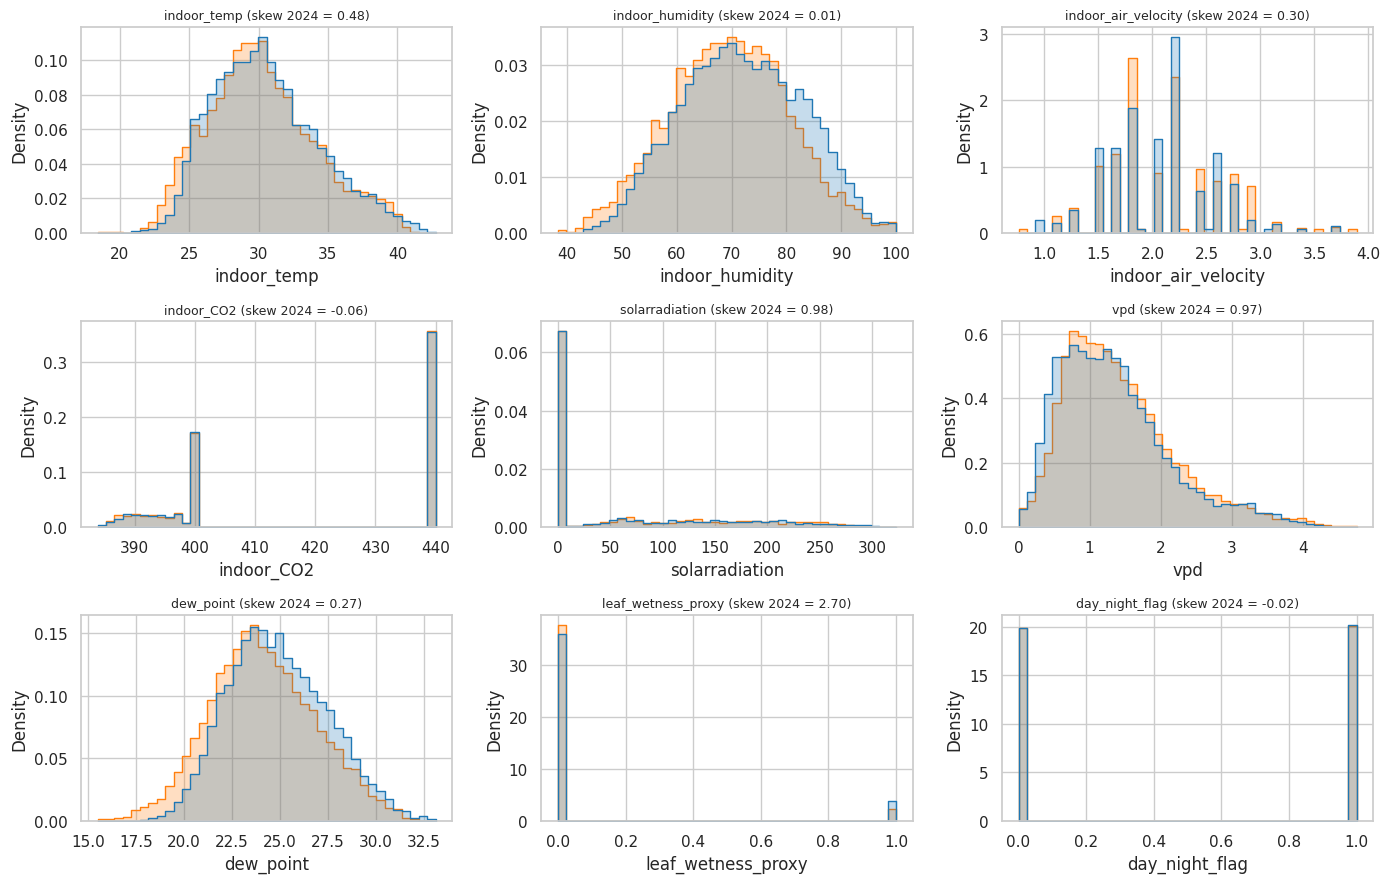

In [26]:
sk = pd.DataFrame({f'{k}_{y}': (RAWALL if k == 'mentah' else MASKALL)[RAWALL.tahun == y][NUM].skew()
                   for k in ('mentah', 'tanpa_mustahil') for y in raw}).round(2)
display(sk)

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, c in zip(axes.ravel(), RAW_FEATURES):
    sns.histplot(data=MASKALL, x=c, hue='tahun', palette=COLORS, bins=40, element='step', stat='density',
                 common_norm=False, legend=False, ax=ax)
    ax.set_title(f'{c} (skew 2024 = {MASKALL.loc[MASKALL.tahun == "2024", c].skew():.2f})', fontsize=9)
plt.tight_layout(); plt.show()

Temuan: skew mentah CO2 (-22) dan suhu (1,3) murni akibat nilai mustahil (-999 dan 85 C). Setelah dibuang, skew CO2 -0,06 dan suhu 0,48. `solarradiation` dan `vpd` miring sekitar 0,97 mengikuti siklus siang-malam, jadi tidak dilakukan transformasi log.

## 2.6 Korelasi antar fitur

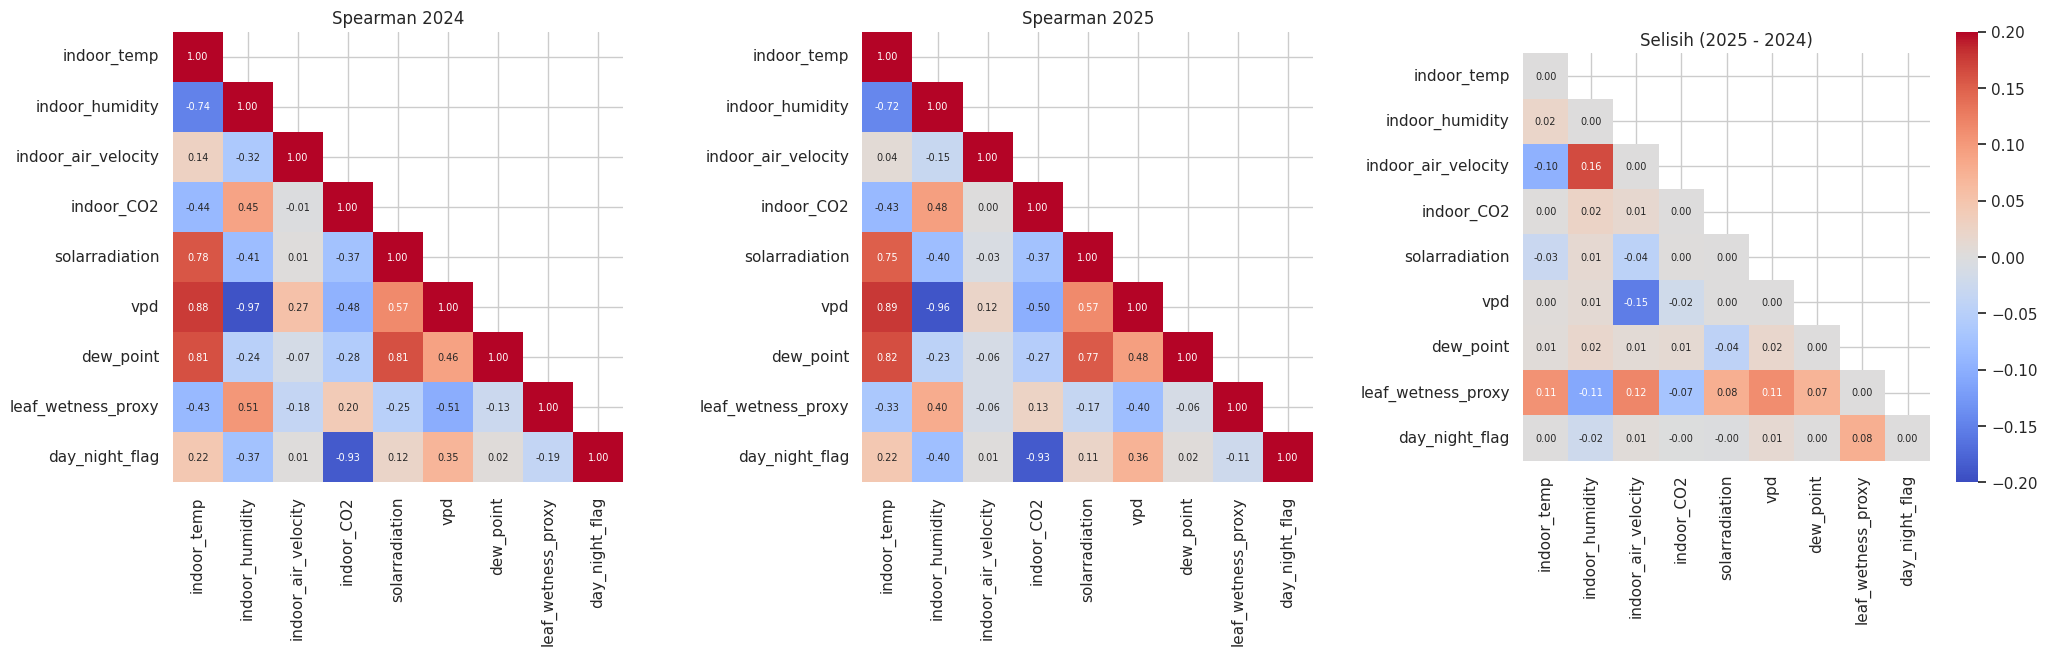

spearman_2024
vpd            indoor_humidity         -0.968
day_night_flag indoor_CO2              -0.932
vpd            indoor_temp              0.881
dew_point      indoor_temp              0.811
               solarradiation           0.809

In [27]:
corr = {y: MASKALL[MASKALL.tahun == y][RAW_FEATURES].corr(method='spearman') for y in raw}
tri = np.triu(np.ones((len(RAW_FEATURES),) * 2, dtype=bool), k=1)

fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
for ax, y in zip(axes[:2], raw):
    sns.heatmap(corr[y], mask=tri, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True,
                annot_kws={'size': 7}, cbar=False, ax=ax); ax.set_title(f'Spearman {y}')
sns.heatmap(corr['2025'] - corr['2024'], mask=tri, annot=True, fmt='.2f', cmap='coolwarm', vmin=-.2, vmax=.2, center=0,
            square=True, annot_kws={'size': 7}, ax=axes[2]); axes[2].set_title('Selisih (2025 - 2024)')
plt.tight_layout(); plt.show()

low = np.tril(np.ones_like(corr['2024'], dtype=bool), k=-1)
pairs = corr['2024'].where(low).stack()
display(pairs[pairs.abs() >= .8].sort_values(key=abs, ascending=False).round(3).to_frame('spearman_2024'))

Temuan: korelasi kuat pada `vpd` vs RH (-0,97), `day_night_flag` vs CO2 (-0,93), `vpd` vs suhu (0,88), `dew_point` vs suhu dan radiasi (0,81). Kolom turunan seperti `vpd` dan `dew_point` tetap dipertahankan karena anomali yang merusak hubungan antar-kanal hanya terlihat bila kanal turunan ikut masuk.

## 2.7 Pola rata-rata per bulan

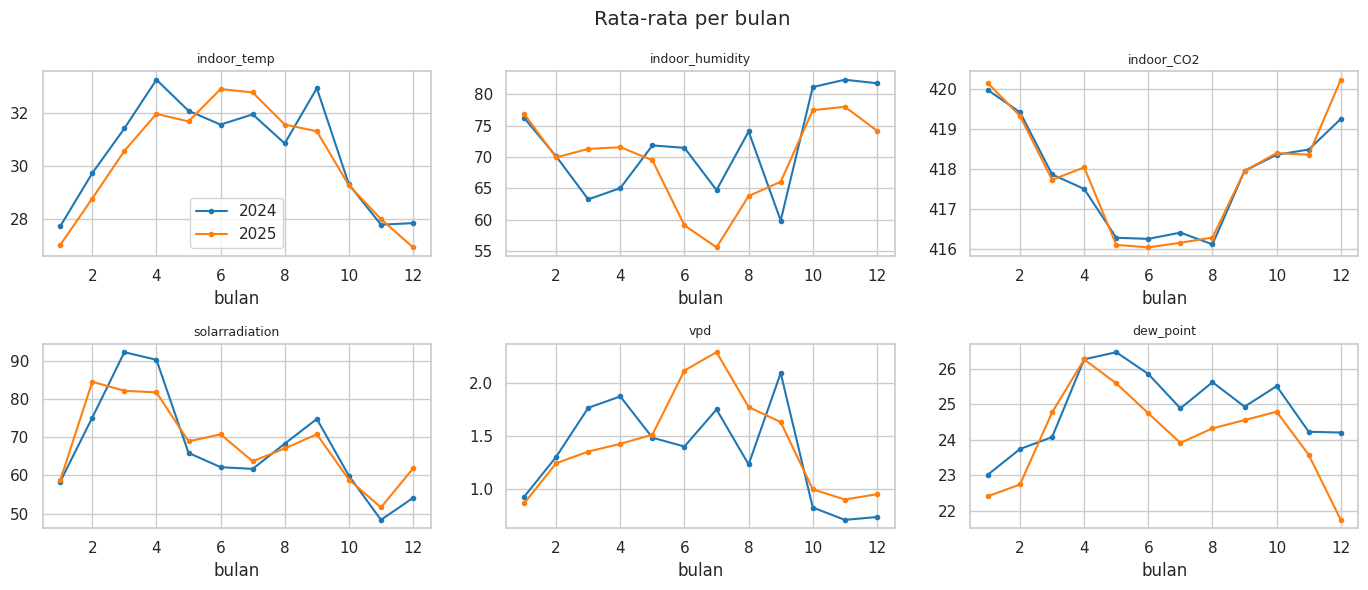

In [28]:
MASKALL['bulan'] = MASKALL['datetime'].dt.month
show = ['indoor_temp', 'indoor_humidity', 'indoor_CO2', 'solarradiation', 'vpd', 'dew_point']
g = MASKALL.groupby(['tahun', 'bulan'])[show].mean()
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, c in zip(axes.ravel(), show):
    for y in raw: ax.plot(g.loc[y].index, g.loc[y, c], marker='o', ms=3, color=COLORS[y], label=y)
    ax.set_title(c, fontsize=9); ax.set_xlabel('bulan')
axes[0, 0].legend(); plt.suptitle('Rata-rata per bulan'); plt.tight_layout(); plt.show()

## 2.8 Pergeseran 2024 ke 2025

In [29]:
a, b = MASKALL[MASKALL.tahun == '2024'][RAW_FEATURES], MASKALL[MASKALL.tahun == '2025'][RAW_FEATURES]
drift = pd.DataFrame({'mean_2024': a.mean(), 'mean_2025': b.mean(), 'selisih': b.mean() - a.mean(),
                      'selisih_x_std2024': ((b.mean() - a.mean()) / a.std()),
                      'KS_stat': {c: stats.ks_2samp(a[c].dropna(), b[c].dropna()).statistic for c in RAW_FEATURES}}).round(3)
display(drift)

,mean_2024,mean_2025,selisih,selisih_x_std2024,KS_stat
indoor_temp,30.536,30.236,-0.301,-0.079,0.042
indoor_humidity,71.821,69.482,-2.339,-0.214,0.089
indoor_air_velocity,2.079,2.125,0.046,0.095,0.069
indoor_CO2,417.815,417.891,0.076,0.003,0.011
solarradiation,67.563,68.235,0.671,0.008,0.016
vpd,1.342,1.423,0.082,0.105,0.058
dew_point,24.902,24.122,-0.780,-0.304,0.115
leaf_wetness_proxy,0.098,0.058,-0.041,-0.137,0.041
day_night_flag,0.504,0.503,-0.001,-0.002,0.001


Temuan: pergeseran 2025 terhadap 2024 kecil. Terbesar `dew_point` (-0,30 std) dan RH (-0,21 std), 2025 sedikit lebih kering dan sejuk. Cukup mirip untuk dipakai sebagai data evaluasi.

# TAHAP 3: Investigasi masalah data

## 3.1 Deret jam-an penuh dan masker nilai mustahil

Duplikat timestamp dibuang, deret di-reindex ke setiap jam, lalu nilai mustahil dijadikan NaN. Hasilnya (`HM`) dipakai untuk investigasi berikutnya. Data asli (`H`) tidak diubah.

In [30]:
def to_hourly(df_raw):
    """Buang timestamp duplikat, urutkan, reindex ke deret jam-an penuh. Return (df_jam, n_duplikat, n_jam_hilang)."""
    d = df_raw.copy()
    n_dup = int(d['datetime'].duplicated().sum())
    d = d.drop_duplicates('datetime', keep='first').sort_values('datetime').set_index('datetime')
    full = pd.date_range(d.index.min(), d.index.max(), freq='h', name='datetime')
    return d.reindex(full), n_dup, len(full) - len(d)

H, BAD, HM = {}, {}, {}
for y, d in raw.items():
    H[y], n_dup, n_ts = to_hourly(d)
    BAD[y] = invalid_mask(H[y])
    HM[y] = H[y].copy()
    HM[y][RAW_FEATURES] = H[y][RAW_FEATURES].mask(BAD[y])
    print(f'{y}: baris mentah={len(raw[y])} | duplikat dibuang={n_dup} | jam hilang ditambahkan={n_ts} | baris sekarang={len(H[y])}')

2024: baris mentah=8782 | duplikat dibuang=4 | jam hilang ditambahkan=6 | baris sekarang=8784
2025: baris mentah=8758 | duplikat dibuang=4 | jam hilang ditambahkan=6 | baris sekarang=8760


## 3.2 Nilai mustahil

,tahun,kolom,jumlah,kejadian_terpisah,nilai_ditemukan,rentang_valid
0,2024,indoor_temp,3,3,[85.0],"(0, 60)"
1,2024,indoor_humidity,3,3,"[108.0, 115.0, 120.0]","(0, 100)"
2,2024,indoor_CO2,2,2,[-999.0],"(250, 2000)"
3,2024,solarradiation,2,2,[-5.0],"(0, 1500)"
4,2025,indoor_temp,3,3,[85.0],"(0, 60)"
5,2025,indoor_humidity,3,3,"[108.0, 120.0]","(0, 100)"
6,2025,indoor_CO2,2,2,[-999.0],"(250, 2000)"
7,2025,solarradiation,2,2,[-5.0],"(0, 1500)"


2024: jumlah kolom mustahil dalam satu baris -> {0: 8774, 1: 10}
2025: jumlah kolom mustahil dalam satu baris -> {0: 8750, 1: 10}


,kolom,waktu,jam_sebelum,nilai_mustahil,jam_sesudah
0,indoor_temp,2024-01-20 10:00:00,29.226841,85.0,30.188332
1,indoor_temp,2024-11-21 00:00:00,23.000000,85.0,22.801924
2,indoor_temp,2024-11-24 11:00:00,31.484543,85.0,31.853777
3,indoor_humidity,2024-03-28 16:00:00,64.500000,115.0,67.000000
4,indoor_humidity,2024-08-24 08:00:00,67.835353,108.0,64.854023
5,indoor_humidity,2024-09-01 23:00:00,75.729629,120.0,71.729629
6,indoor_CO2,2024-09-14 01:00:00,440.000000,-999.0,400.000000
7,indoor_CO2,2024-12-06 08:00:00,397.246165,-999.0,392.476384


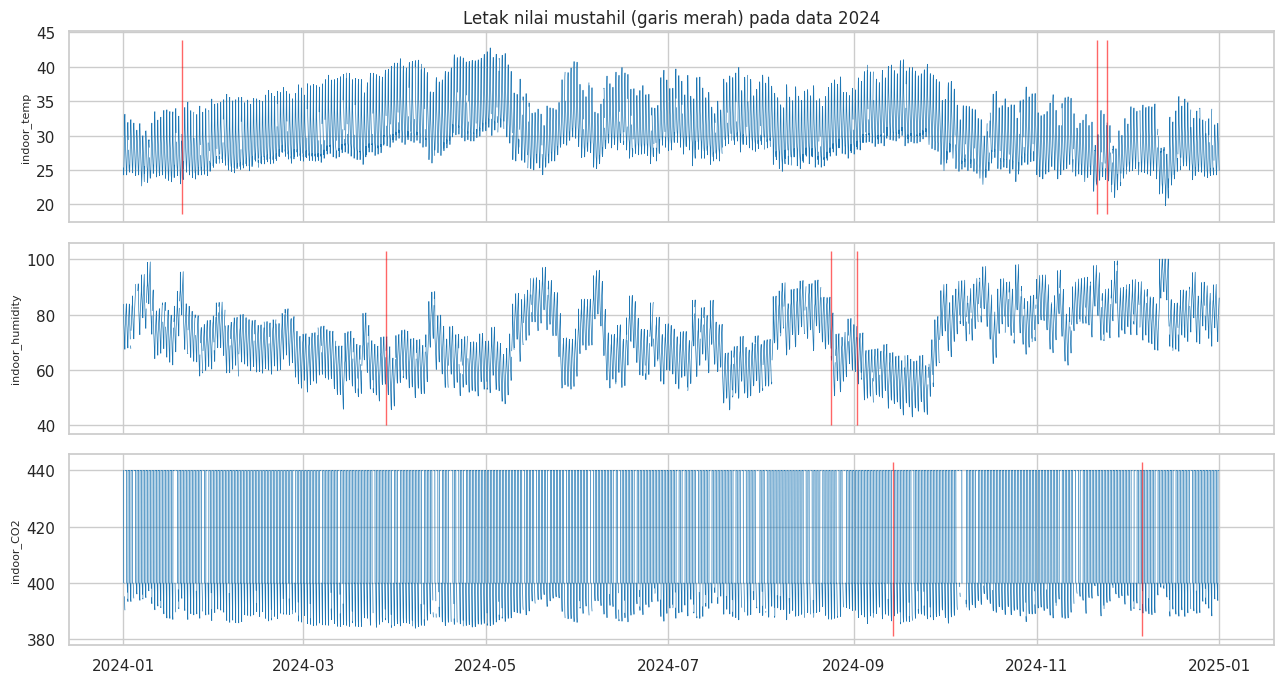

In [31]:
rows = []
for y in H:
    for c in RAW_FEATURES:
        idx = H[y].index[BAD[y][c]]
        if len(idx) == 0: continue
        n_event = int((pd.Series(idx).diff() != pd.Timedelta(hours=1)).sum())
        rows.append({'tahun': y, 'kolom': c, 'jumlah': len(idx), 'kejadian_terpisah': n_event,
                     'nilai_ditemukan': sorted(H[y].loc[idx, c].round(1).unique().tolist())[:6], 'rentang_valid': VALID_RANGE.get(c, (0, 1))})
display(pd.DataFrame(rows))

for y in H:
    print(f'{y}: jumlah kolom mustahil dalam satu baris ->', BAD[y].sum(axis=1).value_counts().sort_index().to_dict())

ctx = []
for c in ['indoor_temp', 'indoor_humidity', 'indoor_CO2']:
    for t in H['2024'].index[BAD['2024'][c]][:3]:
        s = H['2024'][c]
        ctx.append({'kolom': c, 'waktu': t, 'jam_sebelum': s.get(t - pd.Timedelta(hours=1)), 'nilai_mustahil': s[t],
                    'jam_sesudah': s.get(t + pd.Timedelta(hours=1))})
display(pd.DataFrame(ctx))

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
for ax, c in zip(axes, ['indoor_temp', 'indoor_humidity', 'indoor_CO2']):
    ax.plot(HM['2024'][c], lw=.5, color='tab:blue')
    ev = H['2024'].index[BAD['2024'][c]]
    ax.vlines(ev, *ax.get_ylim(), color='red', alpha=.6, lw=1)
    ax.set_ylabel(c, fontsize=8)
axes[0].set_title('Letak nilai mustahil (garis merah) pada data 2024')
plt.tight_layout(); plt.show()

Temuan: ke-10 nilai mustahil per tahun berdiri sendiri (tidak pernah dua kolom sekaligus) dan jam sebelum serta sesudahnya normal, jadi ini glitch satu jam, bukan perubahan kondisi. Layak dijadikan NaN lalu diimputasi.

## 3.3 Missing value dan sensor putus

In [32]:
def longest_gap(s):
    """Panjang rentang NaN berurutan terpanjang (jam)."""
    best = cur = 0
    for v in s.isna().to_numpy():
        cur = cur + 1 if v else 0
        best = max(best, cur)
    return best

def audit_table(d, bad):
    rows = []
    for c in RAW_FEATURES:
        s = d[c].mask(bad[c])
        rows.append({'kolom': c, 'missing_asli': int(d[c].isna().sum()), 'di_luar_rentang': int(bad[c].sum()),
                     'total_tak_valid': int(s.isna().sum()), 'persen_tak_valid': round(100 * s.isna().mean(), 2),
                     'gap_terpanjang_jam': longest_gap(s)})
    return pd.DataFrame(rows).set_index('kolom')

for y in H:
    print(f'===== {y}')
    display(audit_table(H[y], BAD[y]))

===== 2024


,missing_asli,di_luar_rentang,total_tak_valid,persen_tak_valid,gap_terpanjang_jam
kolom,,,,,
indoor_temp,147,3,150,1.71,6
indoor_humidity,159,3,162,1.84,18
indoor_air_velocity,4035,0,4035,45.94,568
indoor_CO2,392,2,394,4.49,30
solarradiation,184,2,186,2.12,6
vpd,93,0,93,1.06,6
dew_point,93,0,93,1.06,6
leaf_wetness_proxy,93,0,93,1.06,6
day_night_flag,92,0,92,1.05,6


===== 2025


,missing_asli,di_luar_rentang,total_tak_valid,persen_tak_valid,gap_terpanjang_jam
kolom,,,,,
indoor_temp,147,3,150,1.71,7
indoor_humidity,158,3,161,1.84,18
indoor_air_velocity,3952,0,3952,45.11,552
indoor_CO2,392,2,394,4.50,30
solarradiation,184,2,186,2.12,6
vpd,93,0,93,1.06,6
dew_point,93,0,93,1.06,6
leaf_wetness_proxy,93,0,93,1.06,6
day_night_flag,93,0,93,1.06,6


In [33]:
def gap_runs(s):
    """Panjang tiap lubang NaN berurutan."""
    na = s.isna(); grp = (~na).cumsum()
    r = na.groupby(grp).sum()
    return r[r > 0]

bins, labels = [0, 1, 3, 6, 24, 10**6], ['1 jam', '2-3 jam', '4-6 jam', '7-24 jam', '>24 jam']
dist = pd.concat({y: pd.DataFrame({c: pd.cut(gap_runs(HM[y][c]), bins=bins, labels=labels).value_counts().reindex(labels)
                                   for c in RAW_FEATURES}).T for y in HM}, axis=1)
print('Jumlah lubang menurut panjangnya')
display(dist.fillna(0).astype(int))

def longest_gap_info(s):
    na = s.isna(); grp = (~na).cumsum(); runs = na.groupby(grp).sum()
    if runs.max() == 0: return pd.Series({'jam': 0, 'mulai': pd.NaT, 'akhir': pd.NaT})
    idx = s.index[(grp == runs.idxmax()) & na]
    return pd.Series({'jam': int(runs.max()), 'mulai': idx[0], 'akhir': idx[-1]})

print('Lubang terpanjang per kolom (2024)')
display(pd.DataFrame({c: longest_gap_info(HM['2024'][c]) for c in RAW_FEATURES}).T)

Jumlah lubang menurut panjangnya


2024                                   2025                                 
                    1 jam 2-3 jam 4-6 jam 7-24 jam >24 jam 1 jam 2-3 jam 4-6 jam 7-24 jam >24 jam
indoor_temp           134       2       2        0       0   129       4       1        1       0
indoor_humidity       132       1       2        1       0   127       3       2        1       0
indoor_air_velocity     0       0       1        0      19     0       0       0        0      21
indoor_CO2            329      11       2        0       1   314      18       1        1       1
solarradiation        173       3       1        0       0   168       5       1        0       0
vpd                    87       0       1        0       0    85       1       1        0       0
dew_point              83       2       1        0       0    87       0       1        0       0
leaf_wetness_proxy     85       1       1        0       0    85       1       1        0       0
day_night_flag         84       1       1        0       0    83       2       1        0       0

Lubang terpanjang per kolom (2024)


,jam,mulai,akhir
indoor_temp,6,2024-12-05 05:00:00,2024-12-05 10:00:00
indoor_humidity,18,2024-01-05 01:00:00,2024-01-05 18:00:00
indoor_air_velocity,568,2024-01-02 06:00:00,2024-01-25 21:00:00
indoor_CO2,30,2024-10-07 03:00:00,2024-10-08 08:00:00
solarradiation,6,2024-12-05 05:00:00,2024-12-05 10:00:00
vpd,6,2024-12-05 05:00:00,2024-12-05 10:00:00
dew_point,6,2024-12-05 05:00:00,2024-12-05 10:00:00
leaf_wetness_proxy,6,2024-12-05 05:00:00,2024-12-05 10:00:00
day_night_flag,6,2024-12-05 05:00:00,2024-12-05 10:00:00


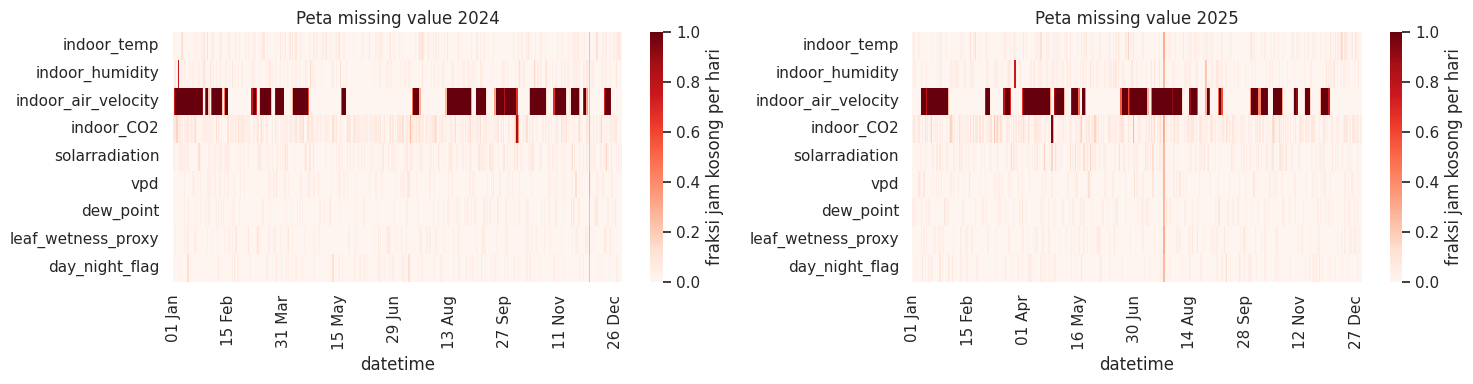

Jumlah jam di mana dua kolom kosong bersamaan (2024), diagonal = total kosong kolom itu


,indoor_temp,indoor_humidity,indoor_air_velocity,indoor_CO2,solarradiation,vpd,dew_point,leaf_wetness_proxy,day_night_flag
indoor_temp,150,8,70,12,6,6,8,8,6
indoor_humidity,8,162,92,16,9,7,7,8,8
indoor_air_velocity,70,92,4035,179,97,41,53,49,45
indoor_CO2,12,16,179,394,13,8,11,12,7
solarradiation,6,9,97,13,186,10,7,7,9
vpd,6,7,41,8,10,93,6,6,7
dew_point,8,7,53,11,7,6,93,7,6
leaf_wetness_proxy,8,8,49,12,7,6,7,93,6
day_night_flag,6,8,45,7,9,7,6,6,92


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, y in zip(axes, HM):
    m = HM[y][RAW_FEATURES].isna().resample('D').mean().T
    m.columns = m.columns.strftime('%d %b')
    sns.heatmap(m, cmap='Reds', vmin=0, vmax=1, xticklabels=45, cbar_kws={'label': 'fraksi jam kosong per hari'}, ax=ax)
    ax.set_title(f'Peta missing value {y}')
plt.tight_layout(); plt.show()

na = HM['2024'][RAW_FEATURES].isna().astype(int)
print('Jumlah jam di mana dua kolom kosong bersamaan (2024), diagonal = total kosong kolom itu')
display(na.T.dot(na))

Temuan: hampir semua lubang hanya 1 jam. Lubang di atas 6 jam hanya RH (18 jam) dan CO2 (30 jam). Gap 6 jam pada 2024-12-05 mengosongkan hampir semua kolom sekaligus (logger mati), sama dengan jam hilang di 2.1.

## 3.4 Nilai identik berurutan (kandidat sensor macet)

Deret panjang bernilai persis sama adalah ciri sensor macet. Pada data normal harus diketahui seberapa panjang deret identik yang wajar, supaya skenario `stuck_sensor` (8 sampai 14 jam) benar-benar berbeda dari kondisi normal. Radiasi hanya dinilai pada siang hari karena nilai 0 di malam hari memang konstan.

,tahun,kolom,run_terpanjang_jam,n_run>=3,n_run>=6,n_run>=8
0,2024,indoor_temp,1,0,0,0
1,2024,indoor_humidity,6,3,1,0
2,2024,dew_point,1,0,0,0
3,2024,vpd,6,3,1,0
4,2024,indoor_CO2,13,806,580,297
5,2024,solarradiation,1,0,0,0
6,2025,indoor_temp,1,0,0,0
7,2025,indoor_humidity,5,2,0,0
8,2025,dew_point,1,0,0,0
9,2025,vpd,5,2,0,0


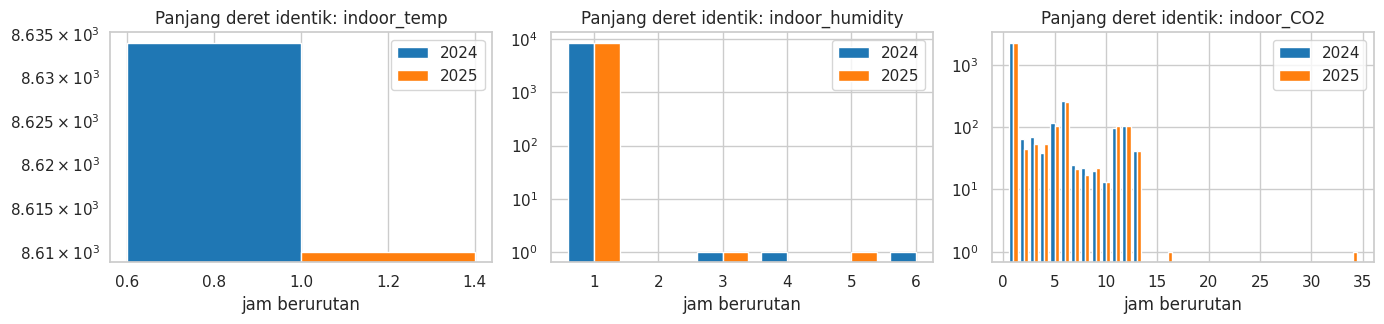

In [35]:
def run_lengths(s):
    """Panjang tiap deret nilai identik berurutan. NaN memutus deret."""
    ok = s.notna()
    grp = ((s != s.shift()) | ~ok).cumsum()
    return s[ok].groupby(grp[ok]).size()

flat_cols = ['indoor_temp', 'indoor_humidity', 'dew_point', 'vpd', 'indoor_CO2', 'solarradiation']
rows, RUNS = [], {}
for y in HM:
    for c in flat_cols:
        s = HM[y][c]
        if c == 'solarradiation': s = s.where(s > 1)
        r = run_lengths(s); RUNS[(y, c)] = r
        rows.append({'tahun': y, 'kolom': c, 'run_terpanjang_jam': int(r.max()), 'n_run>=3': int((r >= 3).sum()),
                     'n_run>=6': int((r >= 6).sum()), 'n_run>=8': int((r >= 8).sum())})
display(pd.DataFrame(rows))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
for ax, c in zip(axes, ['indoor_temp', 'indoor_humidity', 'indoor_CO2']):
    for y in HM:
        vc = RUNS[(y, c)].value_counts().sort_index()
        ax.bar(vc.index + (0.2 if y == '2025' else -0.2), vc.values, width=.4, color=COLORS[y], label=y)
    ax.set_yscale('log'); ax.set_title(f'Panjang deret identik: {c}'); ax.set_xlabel('jam berurutan'); ax.legend()
plt.tight_layout(); plt.show()

Temuan: suhu, titik embun, dan radiasi siang tidak pernah bernilai identik lebih dari 1 jam, RH dan `vpd` paling lama 5 sampai 6 jam. Jadi skenario `stuck_sensor` (8 sampai 14 jam) tidak ada pada data normal dan bisa dibedakan. Pengecualian CO2: deret identik panjang (sampai 13 jam di 2024, 34 jam di 2025) adalah sifat sensornya, lihat 3.5, sehingga CO2 tidak dipakai untuk skenario sensor macet.

## 3.5 Pola CO2 bertingkat

Nilai CO2 yang paling sering muncul, 2024: {440.0: 4164, 400.0: 2027, 396.8: 34, 389.4: 31, 389.2: 29, 397.1: 29}
Nilai CO2 yang paling sering muncul, 2025: {440.0: 4174, 400.0: 2000, 396.7: 36, 396.6: 31, 396.9: 30, 393.2: 28}


datetime,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
min,440.0,400.0,400.0,400.0,400.0,400.0,400.0,395.9,392.0,388.7,386.1,384.5,384.0,385.4,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0
rata2,440.0,408.7,400.0,400.0,400.0,400.0,400.0,397.2,394.7,392.5,390.8,389.7,389.3,424.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0
median,440.0,400.0,400.0,400.0,400.0,400.0,400.0,397.1,394.5,392.2,390.4,389.3,388.9,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0
max,440.0,440.0,400.0,400.0,400.0,400.0,400.0,399.8,399.5,399.3,399.2,399.1,399.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0


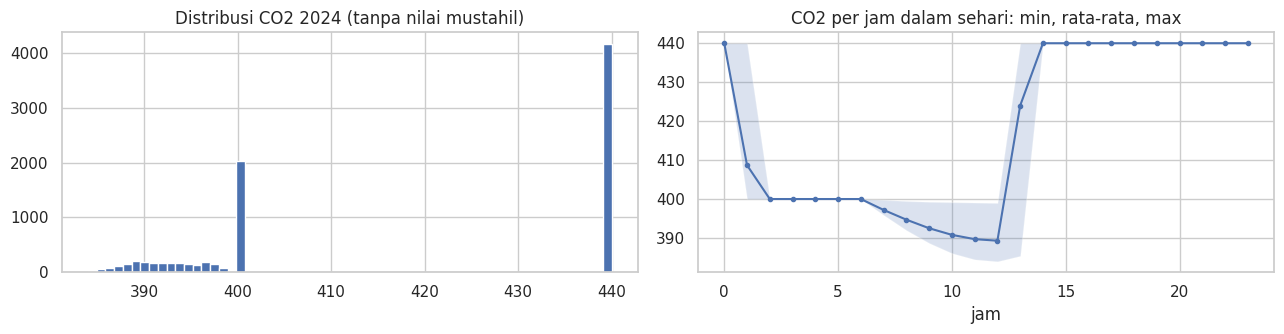

In [36]:
for y in HM:
    print(f'Nilai CO2 yang paling sering muncul, {y}:', HM[y]['indoor_CO2'].round(1).value_counts().head(6).to_dict())

g = HM['2024'].groupby(HM['2024'].index.hour)['indoor_CO2']
prof = pd.DataFrame({'min': g.min(), 'rata2': g.mean(), 'median': g.median(), 'max': g.max()}).round(1)
display(prof.T)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
HM['2024']['indoor_CO2'].hist(bins=60, ax=ax[0]); ax[0].set_title('Distribusi CO2 2024 (tanpa nilai mustahil)')
ax[1].fill_between(prof.index, prof['min'], prof['max'], alpha=.2); ax[1].plot(prof.index, prof['rata2'], 'o-', ms=3)
ax[1].set_title('CO2 per jam dalam sehari: min, rata-rata, max'); ax[1].set_xlabel('jam')
plt.tight_layout(); plt.show()

Temuan: CO2 praktis hanya punya tiga level: 440 ppm (sekitar jam 14 sampai 0), 400 ppm (jam 2 sampai 6), lalu turun pelan dari 399 ke 384 ppm (jam 7 sampai 12). Pola ini ditentukan jam dalam sehari, jadi median per jam adalah pengisi yang tepat dan interpolasi linear tidak.

## 3.6 Makna `day_night_flag`

Deskripsi dataset menyebut 0 = siang dan 1 = malam. Flag dibandingkan dengan jam dan radiasi matahari untuk memastikan.

datetime,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
flag=1 (fraksi),0.00,0.78,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.33,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
radiasi>1 (fraksi),0.00,0.00,0.00,0.0,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.0,0.00,0.00,0.00
radiasi_rata2,0.00,0.00,0.00,0.0,0.00,0.00,0.00,55.18,106.42,151.26,185.26,206.49,213.44,206.07,184.66,150.68,106.69,55.17,0.00,0.00,0.0,0.00,0.00,0.00
leaf_wetness_rata2,0.28,0.17,0.12,0.1,0.05,0.04,0.03,0.02,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.04,0.05,0.08,0.12,0.16,0.2,0.24,0.29,0.31
CO2_rata2,440.00,408.69,400.00,400.0,400.00,400.00,400.00,397.22,394.66,392.46,390.78,389.68,389.31,424.03,440.00,440.00,440.00,440.00,440.00,440.00,440.0,440.00,440.00,440.00


Geser flag sebesar 17 jam memberi korelasi terbesar dengan siang hari: r = -0.96
Tanpa digeser: r = 0.13


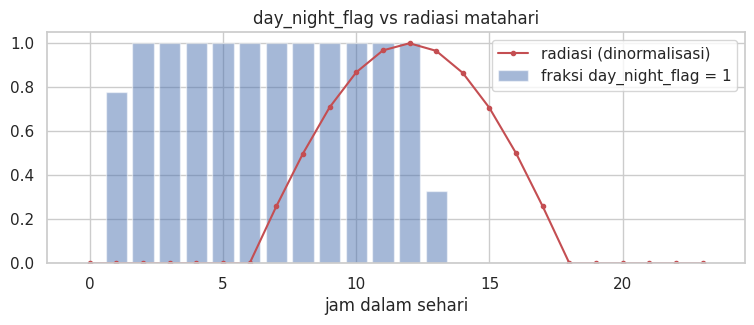

In [37]:
d = HM['2024']
chk = pd.DataFrame({
    'flag=1 (fraksi)':       d.groupby(d.index.hour)['day_night_flag'].mean(),
    'radiasi>1 (fraksi)':    d.groupby(d.index.hour)['solarradiation'].apply(lambda s: (s.dropna() > 1).mean()),
    'radiasi_rata2':         d.groupby(d.index.hour)['solarradiation'].mean(),
    'leaf_wetness_rata2':    d.groupby(d.index.hour)['leaf_wetness_proxy'].mean(),
    'CO2_rata2':             d.groupby(d.index.hour)['indoor_CO2'].mean()}).round(2)
display(chk.T)

pf, ps = chk['flag=1 (fraksi)'].to_numpy(), chk['radiasi>1 (fraksi)'].to_numpy()
cc = np.array([np.corrcoef(np.roll(pf, k), ps)[0, 1] for k in range(24)])
k_best = int(np.argmax(np.abs(cc)))
print(f'Geser flag sebesar {k_best} jam memberi korelasi terbesar dengan siang hari: r = {cc[k_best]:.2f}')
print(f'Tanpa digeser: r = {cc[0]:.2f}')

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(chk.index, chk['flag=1 (fraksi)'], alpha=.5, label='fraksi day_night_flag = 1')
ax.plot(chk.index, chk['radiasi_rata2'] / chk['radiasi_rata2'].max(), 'r-o', ms=3, label='radiasi (dinormalisasi)')
ax.set_xlabel('jam dalam sehari'); ax.legend(); ax.set_title('day_night_flag vs radiasi matahari')
plt.show()

Temuan: `day_night_flag = 1` terjadi sekitar jam 1 sampai 12, sedangkan radiasi baru ada jam 7 sampai 17. Tanpa digeser korelasinya dengan siang hanya 0,13. Flag lebih mirip penanda malam yang bergeser sekitar 7 jam dari matahari, bukan siang. Karena itu siang di notebook ini didefinisikan dari `solarradiation > 1`.

## 3.7 RH jenuh dan leaf wetness

Anomali sintetis `humidity_saturated_day` dan `fungal_risk_day` menaruh RH 100 % di siang hari. Perlu dipastikan kapan RH jenuh terjadi pada data normal.

,tahun,jam_RH_100,saat_radiasi>1,jam_terjadi,run_terpanjang_jam
0,2024,14,0,"[0, 19, 20, 21, 22, 23]",6
1,2025,10,0,"[0, 19, 20, 21, 22, 23]",5


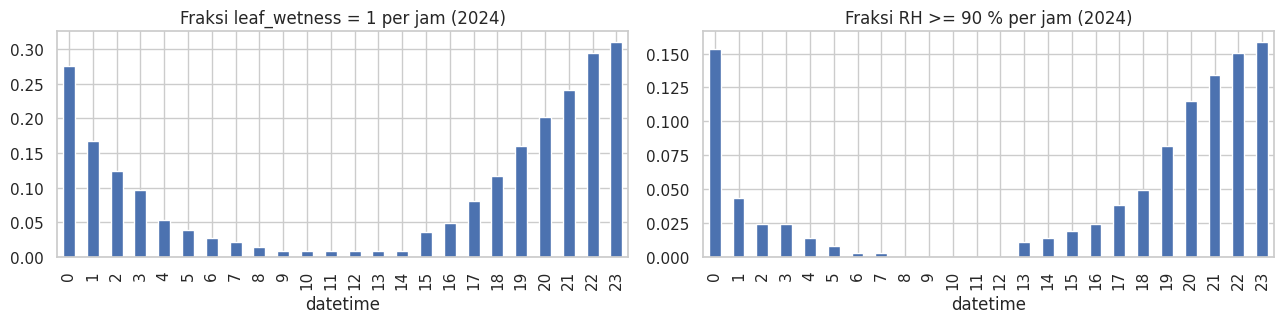

In [38]:
rows = []
for y in HM:
    d = HM[y]; sat = d['indoor_humidity'] >= 99.99
    rows.append({'tahun': y, 'jam_RH_100': int(sat.sum()), 'saat_radiasi>1': int((sat & (d['solarradiation'] > 1)).sum()),
                 'jam_terjadi': sorted(d.index[sat].hour.unique().tolist()),
                 'run_terpanjang_jam': int(run_lengths(d['indoor_humidity'].where(sat)).max())})
display(pd.DataFrame(rows))

d = HM['2024']
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
d.groupby(d.index.hour)['leaf_wetness_proxy'].mean().plot.bar(ax=ax[0], title='Fraksi leaf_wetness = 1 per jam (2024)')
d.groupby(d.index.hour)['indoor_humidity'].apply(lambda s: (s >= 90).mean()).plot.bar(ax=ax[1], title='Fraksi RH >= 90 % per jam (2024)')
plt.tight_layout(); plt.show()

Temuan: RH 100 % hanya terjadi jam 19 sampai 0 dan tidak pernah saat radiasi > 1 (14 jam di 2024, 10 di 2025). Leaf wetness juga menumpuk di malam hari. Jadi RH jenuh di siang hari adalah kondisi yang memang tidak pernah muncul pada data normal, sehingga masuk akal dijadikan anomali.

# TAHAP 4: Pembersihan data

Urutan penting: nilai mustahil menjadi NaN dulu, baru imputasi. Tiap perlakuan dibuktikan pada sel di bawahnya.

| # | Masalah | Perlakuan | Alasan |
|---|---|---|---|
| 1 | Timestamp duplikat | Drop duplikat | Baris ganda membobot ulang jam tertentu |
| 2 | Jam hilang | Reindex ke deret jam-an penuh | Window 24 baris harus sama dengan 24 jam |
| 3 | Nilai mustahil | Jadikan NaN | Error sensor, bukan pengukuran |
| 4 | Kolom terlalu kosong (> 40 %) | Drop kolom | Imputasi separuh data berarti mengarang data |
| 5 | Missing kolom kontinu | Imputasi, metode dipilih lewat uji nyata | Metode terbaik berbeda per kolom dan panjang lubang |
| 6 | Missing kolom biner | Forward-fill <= 6 jam, lalu modus per jam | Interpolasi menghasilkan 0,5 yang bukan kategori |
| 7 | Missing `vpd` | Hitung ulang dari suhu dan RH | `vpd` identik dengan rumus Tetens |
| 8 | Fitur redundan | Drop jika R2 >= 0,99 | Fitur yang pasti bisa ditebak tidak menambah informasi |

## 4.1 Kolom yang dibuang karena terlalu kosong

In [39]:
frac = pd.DataFrame({y: pd.Series({c: H[y][c].mask(BAD[y][c]).isna().mean() for c in RAW_FEATURES}) for y in H})
frac['keputusan'] = np.where(frac.max(axis=1) > DROP_MISSING_FRAC, 'DROP', 'pertahankan')
display(frac.assign(**{y: (100 * frac[y]).round(2) for y in H}).rename(columns={'2024': '% tak valid 2024', '2025': '% tak valid 2025'}))
drop_cols = frac.index[frac.keputusan == 'DROP'].tolist()
print('Kolom dibuang karena terlalu kosong:', drop_cols)
gap = audit_table(H['2024'], BAD['2024']).loc[drop_cols, 'gap_terpanjang_jam']
print('Gap terpanjang kolom yang dibuang (jam):', gap.to_dict(), '= sekitar', int(gap.max() / 24), 'hari tanpa data')

,% tak valid 2024,% tak valid 2025,keputusan
indoor_temp,1.71,1.71,pertahankan
indoor_humidity,1.84,1.84,pertahankan
indoor_air_velocity,45.94,45.11,DROP
indoor_CO2,4.49,4.50,pertahankan
solarradiation,2.12,2.12,pertahankan
vpd,1.06,1.06,pertahankan
dew_point,1.06,1.06,pertahankan
leaf_wetness_proxy,1.06,1.06,pertahankan
day_night_flag,1.05,1.06,pertahankan


Kolom dibuang karena terlalu kosong: ['indoor_air_velocity']
Gap terpanjang kolom yang dibuang (jam): {'indoor_air_velocity': 568} = sekitar 23 hari tanpa data


## 4.2 Memilih metode imputasi dengan masked benchmark

Sel yang nilainya diketahui sengaja dilubangi (1, 4, 12 jam), diisi tiap metode, lalu dibandingkan dengan nilai aslinya (MAE, makin kecil makin baik). Jumlah lubang panjang di data sedikit, jadi angka 12 jam bersifat indikatif.

In [40]:
def masked_benchmark(d_hourly, bad, cols, seed=0, plan=((1, 40), (4, 30), (12, 25))):
    """Lubangi sel yang diketahui, isi dengan 4 metode, hitung MAE per (kolom, panjang lubang)."""
    x = d_hourly.copy()
    for c in RAW_FEATURES: x.loc[bad[c], c] = np.nan
    rng, rows = np.random.default_rng(seed), []
    for c in cols:
        s = x[c].copy(); truth = s.copy(); obs = s.notna().to_numpy(); n = len(s)
        slots, k, holes = rng.permutation(np.arange(0, n - 60, 48)), 0, []
        for L, cnt in plan:
            got = 0
            while got < cnt and k < len(slots):
                st = int(slots[k]) + int(rng.integers(1, 20)); k += 1
                if obs[st - 1:st + L + 1].all(): holes.append((L, st)); got += 1
        lab = pd.Series(0, index=s.index)
        for L, st in holes: s.iloc[st:st + L] = np.nan; lab.iloc[st:st + L] = L
        preds = {'interp': s.interpolate(method='time', limit_area='inside'), 'ffill': s.ffill(),
                 'median_jam': s.fillna(s.groupby(s.index.hour).transform('median')), 'median_global': s.fillna(s.median())}
        for L, _ in plan:
            m = lab == L
            for name, p in preds.items():
                rows.append({'kolom': c, 'lubang_jam': L, 'metode': name, 'n_sel': int(m.sum()), 'MAE': float(np.abs(p[m] - truth[m]).mean())})
    return pd.DataFrame(rows)

bench_cols = [c for c in CONTINUOUS if c not in drop_cols]
bench = masked_benchmark(H['2024'], BAD['2024'], bench_cols)
pv = bench.pivot_table(index=['kolom', 'lubang_jam'], columns='metode', values='MAE')[['interp', 'ffill', 'median_jam', 'median_global']]
display(pv.round(3).style.highlight_min(axis=1, color='#b6e3b6'))

In [41]:
# Kebijakan imputasi per kolom: (metode lubang pendek <= 6 jam, metode lubang panjang > 6 jam)
IMPUTE_POLICY = {
    'indoor_temp':         ('interp',     'median_jam'),
    'indoor_humidity':     ('interp',     'interp'),
    'indoor_CO2':          ('median_jam', 'median_jam'),
    'solarradiation':      ('interp',     'median_jam'),
    'dew_point':           ('interp',     'median_jam'),
    'indoor_air_velocity': ('interp',     'median_jam'),   # kolom ini dibuang, disimpan agar konsisten
}

chk_rows = []
for c in bench_cols:
    b = bench[bench.kolom == c]
    short = b[b.lubang_jam <= 4].groupby('metode').apply(lambda g: np.average(g.MAE, weights=g.n_sel), include_groups=False)
    long_ = b[b.lubang_jam > 4].set_index('metode').MAE
    chk_rows.append({'kolom': c, 'pemenang_pendek': short.idxmin(), 'kebijakan_pendek': IMPUTE_POLICY[c][0],
                     'pemenang_panjang': long_.idxmin(), 'kebijakan_panjang': IMPUTE_POLICY[c][1]})
display(pd.DataFrame(chk_rows).set_index('kolom'))

,pemenang_pendek,kebijakan_pendek,pemenang_panjang,kebijakan_panjang
kolom,,,,
indoor_temp,interp,interp,median_jam,median_jam
indoor_humidity,interp,interp,interp,interp
indoor_CO2,median_jam,median_jam,median_jam,median_jam
solarradiation,interp,interp,median_jam,median_jam
dew_point,interp,interp,median_jam,median_jam


Temuan: kebijakan per kolom sama dengan pemenang benchmark. Lubang pendek pada suhu, RH, titik embun, radiasi paling akurat dengan interpolasi. CO2 memakai median per jam. Lubang panjang pada suhu, titik embun, radiasi memakai median per jam karena garis lurus 12 jam melewati siklus siang-malam.

## 4.3 Terapkan imputasi dan hitung ulang `vpd`

Lebih dulu dibuktikan bahwa rumus Tetens identik dengan kolom `vpd` pada baris yang lengkap.

In [42]:
def vpd_from(t, rh):
    """VPD (kPa) dari suhu (C) dan RH (%), rumus Tetens."""
    return (0.6108 * np.exp(17.27 * t / (t + 237.3)) * (1 - rh / 100)).clip(lower=0)

def impute_continuous(s, short, long, limit=INTERP_LIMIT_H):
    """Lubang <= limit jam memakai metode `short`, lubang lebih panjang memakai `long`."""
    na = s.isna()
    run = na.astype(int).groupby((~na).cumsum()).transform('sum')
    fills = {'interp': s.interpolate(method='time', limit_area='inside'),
             'median_jam': s.groupby(s.index.hour).transform('median')}
    out = s.copy()
    out[na & (run <= limit)] = fills[short][na & (run <= limit)]
    out[na & (run > limit)] = fills[long][na & (run > limit)]
    return out.fillna(fills['median_jam'])

def impute_binary(s, limit=INTERP_LIMIT_H):
    """Kolom biner: forward-fill <= limit jam, sisanya modus per jam dalam sehari. Hasil tetap 0/1."""
    out = s.ffill(limit=limit)
    mode_h = s.groupby(s.index.hour).agg(lambda x: x.mode().iloc[0])
    still = out.isna()
    out[still] = s.index[still].hour.map(mode_h).to_numpy()
    return out.astype(int)

def clean_year(d_hourly, drop_cols):
    """Satu tahun: sel tak valid -> NaN, buang drop_cols, imputasi sesuai IMPUTE_POLICY, hitung ulang vpd."""
    d = d_hourly.copy()
    bad = invalid_mask(d)
    for c in RAW_FEATURES:
        d.loc[bad[c], c] = np.nan
    d = d.drop(columns=list(drop_cols))
    for c in d.columns:
        if c == 'vpd':
            continue
        d[c] = impute_binary(d[c]) if c in BINARY else impute_continuous(d[c], *IMPUTE_POLICY[c])
    if 'vpd' in d:
        d['vpd'] = vpd_from(d['indoor_temp'], d['indoor_humidity'])
    return d

ok = H['2024'][['indoor_temp', 'indoor_humidity', 'vpd']].where(~BAD['2024'][['indoor_temp', 'indoor_humidity', 'vpd']]).dropna()
print('Selisih maks |vpd_rumus - vpd_data| pada', len(ok), 'baris lengkap =', float((vpd_from(ok.indoor_temp, ok.indoor_humidity) - ok.vpd).abs().max()))

d24 = clean_year(H['2024'], drop_cols)
d25 = clean_year(H['2025'], drop_cols)
print('Sisa NaN setelah imputasi: 2024 =', int(d24.isna().sum().sum()), '| 2025 =', int(d25.isna().sum().sum()))
print('Kolom tersisa:', d24.columns.tolist())

Selisih maks |vpd_rumus - vpd_data| pada 8394 baris lengkap = 4.884981308350689e-15
Sisa NaN setelah imputasi: 2024 = 0 | 2025 = 0
Kolom tersisa: ['indoor_temp', 'indoor_humidity', 'indoor_CO2', 'solarradiation', 'day_night_flag', 'vpd', 'dew_point', 'leaf_wetness_proxy']


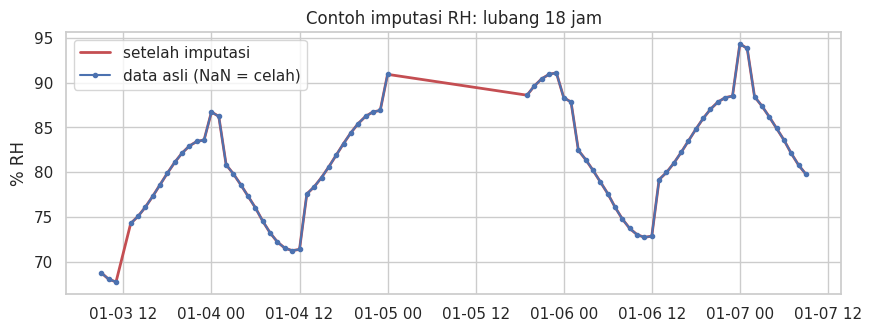

In [43]:
# Contoh visual: lubang terpanjang pada kelembapan (RH) tahun 2024
s_raw = HM['2024']['indoor_humidity']
na = s_raw.isna(); run = na.astype(int).groupby((~na).cumsum()).transform('sum')
mid = run.idxmax() + pd.Timedelta(hours=int(run.max() // 2))
w = slice(mid - pd.Timedelta(hours=48), mid + pd.Timedelta(hours=48))
plt.figure(figsize=(10, 3.4))
plt.plot(d24.loc[w, 'indoor_humidity'], 'r-', lw=2, label='setelah imputasi')
plt.plot(s_raw.loc[w], 'b.-', label='data asli (NaN = celah)')
plt.title(f'Contoh imputasi RH: lubang {int(run.max())} jam'); plt.ylabel('% RH'); plt.legend(); plt.show()

## 4.4 Cek redundansi fitur dan penetapan `FEATURES`

`day_night_flag` diuji dengan pertanyaan: seberapa baik ia bisa ditebak dari fitur lain (Random Forest, 3-fold CV, R2)? `vpd` dan `dew_point` adalah turunan suhu dan RH tetapi sengaja dipertahankan, karena skenario seperti `stuck_sensor` dan `fungal_risk_day` merusak konsistensi antar-kanal, dan konsistensi itu hanya terlihat bila kanal turunan ikut masuk.

In [44]:
def redundancy_r2(d, target, seed=0):
    """R2 (cross-validation) merekonstruksi target dari fitur lain. Tinggi (>= 0.99) = fitur redundan."""
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import cross_val_score
    return float(cross_val_score(RandomForestRegressor(100, max_depth=12, n_jobs=-1, random_state=seed),
                                 d.drop(columns=[target]), d[target], cv=3, scoring='r2').mean())

r2_flag = redundancy_r2(d24, 'day_night_flag')
print(f'R2 day_night_flag dari fitur lain = {r2_flag:.4f} (batas {REDUNDANCY_R2}) ->', 'DROP (redundan)' if r2_flag >= REDUNDANCY_R2 else 'dipertahankan')
drop_redundant = ['day_night_flag'] if r2_flag >= REDUNDANCY_R2 else []
df24, df25 = d24.drop(columns=drop_redundant), d25.drop(columns=drop_redundant)

FEATURES   = [c for c in RAW_FEATURES if c in df24.columns]     # urutan ini = urutan kanal pada window
df24, df25 = df24[FEATURES], df25[FEATURES]                      # samakan urutan kolom dengan FEATURES
N_FEATURES = len(FEATURES)
IX = {name: i for i, name in enumerate(FEATURES)}

ringkas = pd.DataFrame({
    'aksi': {c: ('DROP (missing > 40 %)' if c in drop_cols else 'DROP (redundan)' if c in drop_redundant else
                 'HITUNG ULANG (Tetens)' if c == 'vpd' else 'IMPUTASI biner (ffill <= 6 jam, modus per jam)' if c in BINARY else
                 f'IMPUTASI {IMPUTE_POLICY[c][0]} / {IMPUTE_POLICY[c][1]}') for c in RAW_FEATURES},})
display(ringkas)
print(f'FEATURES final ({N_FEATURES}):', FEATURES)

# Penanda sel hasil imputasi (dipakai untuk menilai kualitas window di Tahap 7)
IMP = {'2024': HM['2024'][FEATURES].isna(), '2025': HM['2025'][FEATURES].isna()}
print('\n% sel hasil imputasi per fitur:')
display(pd.DataFrame({y: (100 * IMP[y].mean()).round(2) for y in IMP}).T)

R2 day_night_flag dari fitur lain = 0.9874 (batas 0.99) -> dipertahankan


,aksi
indoor_temp,IMPUTASI interp / median_jam
indoor_humidity,IMPUTASI interp / interp
indoor_air_velocity,DROP (missing > 40 %)
indoor_CO2,IMPUTASI median_jam / median_jam
solarradiation,IMPUTASI interp / median_jam
vpd,HITUNG ULANG (Tetens)
dew_point,IMPUTASI interp / median_jam
leaf_wetness_proxy,"IMPUTASI biner (ffill <= 6 jam, modus per jam)"
day_night_flag,"IMPUTASI biner (ffill <= 6 jam, modus per jam)"


FEATURES final (8): ['indoor_temp', 'indoor_humidity', 'indoor_CO2', 'solarradiation', 'vpd', 'dew_point', 'leaf_wetness_proxy', 'day_night_flag']

% sel hasil imputasi per fitur:


,indoor_temp,indoor_humidity,indoor_CO2,solarradiation,vpd,dew_point,leaf_wetness_proxy,day_night_flag
2024,1.71,1.84,4.49,2.12,1.06,1.06,1.06,1.05
2025,1.71,1.84,4.50,2.12,1.06,1.06,1.06,1.06


Temuan: `day_night_flag` bisa ditebak dari fitur lain dengan R2 = 0,987, sangat dekat tetapi di bawah ambang 0,99, jadi dipertahankan. Fitur final 8: suhu, RH, CO2, radiasi, `vpd`, `dew_point`, `leaf_wetness_proxy`, `day_night_flag`. `indoor_air_velocity` dibuang (45 % kosong, 23 hari tanpa data).

# TAHAP 5: Data bersih

## 5.1 Validasi dan perbandingan sebelum dan sesudah pembersihan

In [45]:
def check_clean(df):
    """Validasi akhir: deret jam-an kontinu, tanpa NaN, semua nilai di rentang fisik, biner hanya 0/1."""
    gaps = df.index.to_series().diff().dropna().value_counts()
    assert len(gaps) == 1 and gaps.index[0] == pd.Timedelta(hours=1), f'Deret waktu tidak kontinu: {gaps}'
    assert df[FEATURES].isna().sum().sum() == 0, 'Masih ada NaN'
    for c, (lo, hi) in VALID_RANGE.items():
        if c in FEATURES: assert df[c].between(lo, hi).all(), f'{c} di luar rentang'
    for c in BINARY:
        if c in FEATURES: assert df[c].isin([0, 1]).all(), f'{c} bukan biner'
    return df

df24, df25 = check_clean(df24), check_clean(df25)
print('2024:', df24.shape, df24.index.min(), 'sampai', df24.index.max())
print('2025:', df25.shape, df25.index.min(), 'sampai', df25.index.max())

for y, dc in (('2024', df24), ('2025', df25)):
    before = HM[y][FEATURES]
    print(f'\n===== {y}: sebelum (nilai mustahil = NaN) vs sesudah imputasi')
    display(pd.DataFrame({'mean_sebelum': before.mean(), 'mean_sesudah': dc.mean(), 'std_sebelum': before.std(),
                          'std_sesudah': dc.std(), 'min_sesudah': dc.min(), 'max_sesudah': dc.max()}).round(3))
    dcorr = (dc.corr(method='spearman') - before.corr(method='spearman')).abs().max().max()
    print(f'Selisih korelasi Spearman terbesar sebelum vs sesudah imputasi: {dcorr:.4f}')

2024: (8784, 8) 2024-01-01 00:00:00 sampai 2024-12-31 23:00:00
2025: (8760, 8) 2025-01-01 00:00:00 sampai 2025-12-31 23:00:00

===== 2024: sebelum (nilai mustahil = NaN) vs sesudah imputasi


,mean_sebelum,mean_sesudah,std_sebelum,std_sesudah,min_sesudah,max_sesudah
indoor_temp,30.538,30.536,3.820,3.813,19.802,42.752
indoor_humidity,71.815,71.869,10.944,10.951,43.043,100.000
indoor_CO2,417.813,417.795,22.277,22.276,383.990,440.000
solarradiation,67.571,67.577,88.358,88.154,0.000,320.200
vpd,1.342,1.341,0.778,0.778,0.000,4.378
dew_point,24.902,24.907,2.571,2.568,17.846,33.120
leaf_wetness_proxy,0.098,0.098,0.298,0.298,0.000,1.000
day_night_flag,0.504,0.505,0.500,0.500,0.000,1.000


Selisih korelasi Spearman terbesar sebelum vs sesudah imputasi: 0.0045

===== 2025: sebelum (nilai mustahil = NaN) vs sesudah imputasi


,mean_sebelum,mean_sesudah,std_sebelum,std_sesudah,min_sesudah,max_sesudah
indoor_temp,30.236,30.230,3.908,3.910,18.402,41.168
indoor_humidity,69.481,69.476,10.876,10.860,38.321,100.000
indoor_CO2,417.891,417.849,22.319,22.318,383.860,440.000
solarradiation,68.232,68.409,89.088,89.051,0.000,322.800
vpd,1.423,1.422,0.783,0.781,0.000,4.757
dew_point,24.122,24.121,2.750,2.749,15.508,32.285
leaf_wetness_proxy,0.058,0.057,0.233,0.232,0.000,1.000
day_night_flag,0.503,0.503,0.500,0.500,0.000,1.000


Selisih korelasi Spearman terbesar sebelum vs sesudah imputasi: 0.0080


Temuan: imputasi hampir tidak mengubah distribusi (rata-rata berubah kurang dari 0,3 %, std nyaris sama), jadi tidak ada pergeseran buatan akibat pengisian.

## 5.2 Deret waktu dan profil harian

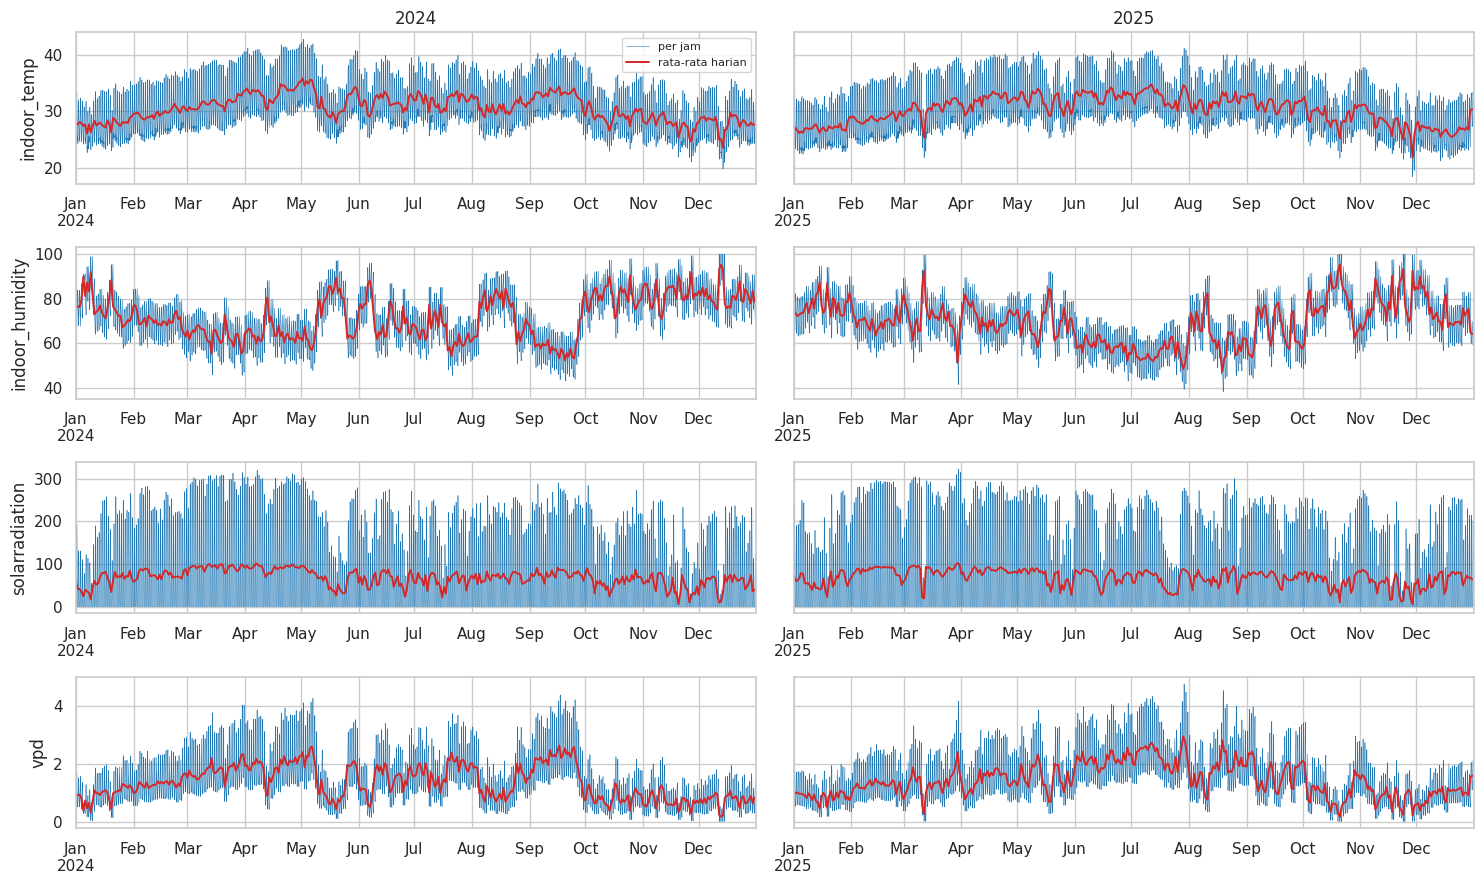

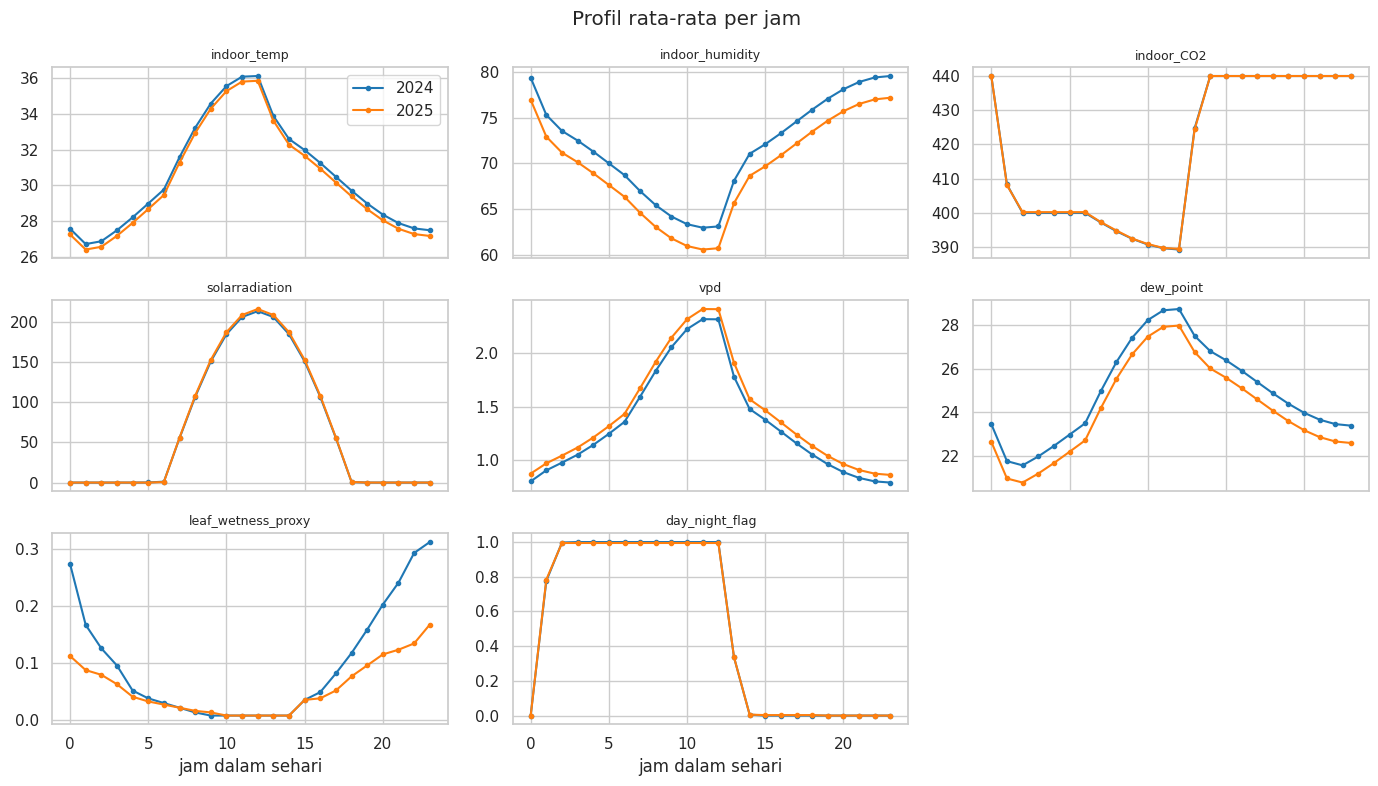

In [46]:
cols4 = ['indoor_temp', 'indoor_humidity', 'solarradiation', 'vpd']
fig, axes = plt.subplots(4, 2, figsize=(15, 9), sharey='row')
for j, (y, dc) in enumerate((('2024', df24), ('2025', df25))):
    for i, col in enumerate(cols4):
        ax = axes[i, j]
        dc[col].plot(ax=ax, lw=.4, color='tab:blue', label='per jam')
        dc[col].resample('D').mean().plot(ax=ax, lw=1.4, color='tab:red', label='rata-rata harian')
        ax.set_ylabel(col if j == 0 else ''); ax.set_xlabel('')
    axes[0, j].set_title(y)
axes[0, 0].legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(3, 3, figsize=(14, 8), sharex=True)
for ax in axes.ravel()[N_FEATURES:]: ax.axis('off')
for ax, col in zip(axes.ravel(), FEATURES):
    for y, dc in (('2024', df24), ('2025', df25)):
        h = dc.groupby(dc.index.hour)[col].mean()
        ax.plot(h.index, h.values, marker='o', ms=3, color=COLORS[y], label=y)
    ax.set_title(col, fontsize=9)
for ax in axes[-1]: ax.set_xlabel('jam dalam sehari')
axes[0, 0].legend(); plt.suptitle('Profil rata-rata per jam'); plt.tight_layout(); plt.show()

## 5.3 Periodisitas seluruh deret (FFT)

indoor_temp: 3 periode dominan (<= 72 jam) = [24. 12.  8.]
indoor_humidity: 3 periode dominan (<= 72 jam) = [24.   8.   4.8]
solarradiation: 3 periode dominan (<= 72 jam) = [24.  12.  23.9]


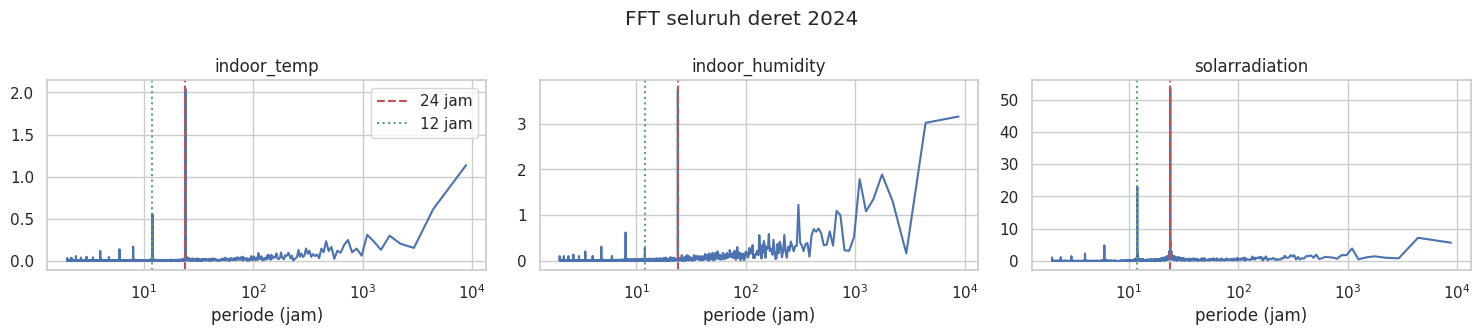

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for ax, ch in zip(axes, ['indoor_temp', 'indoor_humidity', 'solarradiation']):
    x = df24[ch].to_numpy()
    amp = np.abs(np.fft.rfft(x - x.mean())) / len(x)
    freq = np.fft.rfftfreq(len(x), d=1.0)
    ax.semilogx(1 / freq[1:], amp[1:]); ax.axvline(24, color='r', ls='--', label='24 jam'); ax.axvline(12, color='g', ls=':', label='12 jam')
    ax.set_title(ch); ax.set_xlabel('periode (jam)')
    per = 1 / freq[1:]; sel = np.where(per <= 72)[0]
    top = sel[np.argsort(amp[1:][sel])[::-1][:3]]
    print(f'{ch}: 3 periode dominan (<= 72 jam) =', np.round(per[top], 1))
axes[0].legend(); plt.suptitle('FFT seluruh deret 2024'); plt.tight_layout(); plt.show()

Temuan: siklus 24 jam dominan pada suhu, RH, dan radiasi (radiasi juga punya harmonik 12 jam). Ini alasan window 24 jam dipilih.

## 5.4 Simpan data bersih

Data bersih disimpan ke CSV di `datasets/clean/` supaya tidak hilang saat runtime Colab berakhir dan bisa dipanggil notebook lain. Ikut disimpan penanda sel yang diisi imputasi (`*_imputed_mask.csv`) agar jejak pembersihan tetap bisa ditelusuri.

In [48]:
os.makedirs(CLEAN_DIR, exist_ok=True)
CLEAN_FILES = {}
for y, dc in (('2024', df24), ('2025', df25)):
    f_clean = f'{CLEAN_DIR}/dindigul_greenhouse_indoor_{y}_clean.csv'
    f_mask  = f'{CLEAN_DIR}/dindigul_greenhouse_indoor_{y}_imputed_mask.csv'
    out = dc[FEATURES].copy()
    for c_ in BINARY:
        if c_ in out: out[c_] = out[c_].astype(int)
    out.to_csv(f_clean, index_label='datetime')
    IMP[y].astype(int).to_csv(f_mask, index_label='datetime')
    CLEAN_FILES[y] = f_clean

def load_clean(year):
    # Muat data bersih (index datetime per jam, kolom FEATURES). Dipakai juga oleh Notebook 2 dan 3.
    return pd.read_csv(f'{CLEAN_DIR}/dindigul_greenhouse_indoor_{year}_clean.csv', index_col='datetime', parse_dates=True)

# Verifikasi: baca ulang dan bandingkan dengan yang di memori
for y, dc in (('2024', df24), ('2025', df25)):
    back = load_clean(y)
    assert back.shape == dc.shape and list(back.columns) == FEATURES
    assert np.allclose(back.to_numpy(float), dc[FEATURES].to_numpy(float)) and back.isna().sum().sum() == 0
    assert (back.index.to_series().diff().dropna() == pd.Timedelta(hours=1)).all()
    print(f'{y}: {back.shape} tersimpan dan terbaca ulang dengan benar ->', CLEAN_FILES[y])
print('Isi folder:', sorted(os.listdir(CLEAN_DIR)))

2024: (8784, 8) tersimpan dan terbaca ulang dengan benar -> /content/drive/MyDrive/greenhouse-anomaly-edgeai-main/datasets/clean/dindigul_greenhouse_indoor_2024_clean.csv
2025: (8760, 8) tersimpan dan terbaca ulang dengan benar -> /content/drive/MyDrive/greenhouse-anomaly-edgeai-main/datasets/clean/dindigul_greenhouse_indoor_2025_clean.csv
Isi folder: ['dindigul_greenhouse_indoor_2024_clean.csv', 'dindigul_greenhouse_indoor_2024_imputed_mask.csv', 'dindigul_greenhouse_indoor_2025_clean.csv', 'dindigul_greenhouse_indoor_2025_imputed_mask.csv', 'feature_analysis_config.json']


# TAHAP 6: Window, split, dan kebocoran data

## 6.1 Fungsi window dan split berbasis blok

Window dengan hop 1 jam saling tumpang-tindih 23 dari 24 jam. Split acak per window membuat window uji hampir identik dengan window latih. Solusinya membagi deret menjadi blok 7 hari dulu, baru window dibuat di dalam blok.

In [49]:
def make_windows(data, window_length, hop):
    """Sliding window -> array 3D (n_windows, window_length, n_features). data: DataFrame (kolom FEATURES) atau ndarray."""
    if isinstance(data, pd.DataFrame):
        data = data[FEATURES].to_numpy(dtype=np.float32)
    v = np.lib.stride_tricks.sliding_window_view(data, window_length, axis=0)   # (N-W+1, F, W)
    return np.ascontiguousarray(v[::hop].transpose(0, 2, 1)).astype(np.float32)

def split_into_blocks(values, block_hours, window_length):
    """Potong deret menjadi blok berurutan. Sisa di ujung dipakai jika masih cukup untuk satu window."""
    n = len(values) // block_hours
    blocks = [values[i * block_hours:(i + 1) * block_hours] for i in range(n)]
    rest = values[n * block_hours:]
    if len(rest) >= window_length:
        blocks.append(rest)
    return blocks

def assign_blocks(n_blocks, ratios, seed=42):
    """Acak indeks blok lalu bagi sesuai ratios (dict nama -> rasio; sisa masuk ke split pertama)."""
    idx = np.random.default_rng(seed).permutation(n_blocks)
    names = list(ratios)
    counts = {k: int(round(n_blocks * ratios[k])) for k in names[1:]}
    counts[names[0]] = n_blocks - sum(counts.values())
    out, start = {}, 0
    for k in names:
        out[k] = sorted(idx[start:start + counts[k]].tolist()); start += counts[k]
    assert sum(len(v) for v in out.values()) == n_blocks
    return out

def windows_from_blocks(blocks, window_length, hop):
    return np.concatenate([make_windows(b, window_length, hop) for b in blocks], axis=0)

## 6.2 Bukti kebocoran pada split acak per window

Untuk tiap window uji dicek apakah ada window latih yang berbagi jam yang sama dengannya.

In [50]:
W = window_length_hours
n_win = len(df24) - W + 1
ratios = {'train': 1 - val_ratio - test_ratio, 'val': val_ratio, 'test': test_ratio}

def overlap_fraction(is_train, is_test, min_shared):
    """Fraksi window uji yang berbagi >= min_shared jam dengan minimal satu window latih."""
    reach = W - min_shared                                   # selisih awal window maksimum yang masih berbagi >= min_shared jam
    near = np.convolve(is_train.astype(int), np.ones(2 * reach + 1, int), mode='same') > 0
    return float(near[is_test].mean())

# (a) split acak per window
r = np.random.default_rng(SEED).random(n_win)
tr_a, te_a = r >= (val_ratio + test_ratio), r < test_ratio

# (b) split per blok 7 hari
blocks24 = split_into_blocks(df24[FEATURES].to_numpy(np.float32), block_hours, W)
assign = assign_blocks(len(blocks24), ratios, seed=SEED)
tr_b, te_b = np.zeros(n_win, bool), np.zeros(n_win, bool)
for k, flag in (('train', tr_b), ('test', te_b)):
    for i in assign[k]:
        off = i * block_hours
        flag[off: off + len(blocks24[i]) - W + 1] = True

print(pd.DataFrame({
    'split acak per window': [overlap_fraction(tr_a, te_a, 1), overlap_fraction(tr_a, te_a, 12)],
    'split per blok 7 hari': [overlap_fraction(tr_b, te_b, 1), overlap_fraction(tr_b, te_b, 12)]},
    index=['berbagi >= 1 jam', 'berbagi >= 12 jam']).round(3))

                   split acak per window  split per blok 7 hari
berbagi >= 1 jam                     1.0                    0.0
berbagi >= 12 jam                    1.0                    0.0


## 6.3 Pembagian blok train, val, test

Jumlah blok 2024: 53 {'train': 37, 'val': 8, 'test': 8}
Jumlah window per split: {'train': 5245, 'val': 1160, 'test': 1160}


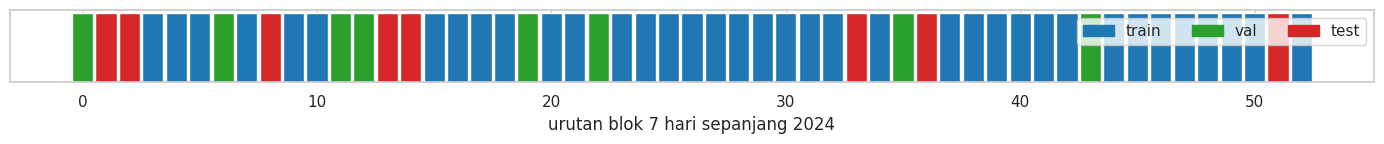

In [51]:
print('Jumlah blok 2024:', len(blocks24), {k: len(v) for k, v in assign.items()})
print('Jumlah window per split:', {k: sum(len(blocks24[i]) - W + 1 for i in v) for k, v in assign.items()})

col = {'train': 'tab:blue', 'val': 'tab:green', 'test': 'tab:red'}
who = {i: k for k, v in assign.items() for i in v}
fig, ax = plt.subplots(figsize=(14, 1.6))
ax.bar(range(len(blocks24)), 1, color=[col[who[i]] for i in range(len(blocks24))], width=.9)
ax.set_yticks([]); ax.set_xlabel('urutan blok 7 hari sepanjang 2024')
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in col.values()], labels=list(col), ncol=3, loc='upper right')
plt.tight_layout(); plt.show()

## 6.4 Pergeseran antar split dan ke 2025

In [52]:
sv = {k: np.concatenate([blocks24[i] for i in assign[k]]) for k in assign}
mu, sd = sv['train'].mean(0), sv['train'].std(0)
drift_split = pd.DataFrame({
    'train_mean': mu, 'val_mean': sv['val'].mean(0), 'test_mean': sv['test'].mean(0),
    'val_vs_train (x std)': (sv['val'].mean(0) - mu) / sd,
    'test_vs_train (x std)': (sv['test'].mean(0) - mu) / sd,
    '2025_vs_train (x std)': (df25[FEATURES].mean().to_numpy() - mu) / sd}, index=FEATURES)
display(drift_split.round(3))

,train_mean,val_mean,test_mean,val_vs_train (x std),test_vs_train (x std),2025_vs_train (x std)
indoor_temp,30.608999,30.381001,30.363001,-0.059,-0.064,-0.099
indoor_humidity,71.886002,72.396004,71.263000,0.047,-0.057,-0.222
indoor_CO2,417.561005,418.135010,418.511993,0.026,0.043,0.013
solarradiation,66.501999,68.208000,71.821999,0.020,0.061,0.022
vpd,1.346000,1.294000,1.361000,-0.067,0.019,0.097
dew_point,24.987000,24.836000,24.618000,-0.059,-0.144,-0.338
leaf_wetness_proxy,0.098000,0.115000,0.083000,0.060,-0.048,-0.136
day_night_flag,0.511000,0.500000,0.483000,-0.021,-0.056,-0.015


Temuan: pada split acak per window, 100 % window uji berbagi jam dengan window latih. Pada split blok 7 hari angkanya 0 %. Selisih rata-rata antar split kecil (di bawah 0,15 std), sedangkan 2025 terhadap train paling jauh di `dew_point` (-0,34 std), jadi 2025 layak sebagai evaluasi yang sedikit bergeser.

# TAHAP 7: Window, anomali sintetis, dan fitur statistik

## 7.1 Membuat window

`window_length_hours = 24` dan `hop_hours = 1`: tiap window satu hari penuh, window berikutnya bergeser satu jam.

| Window | Kelebihan | Kekurangan |
|---|---|---|
| Pendek (6 sampai 12 jam) | Peka pada anomali singkat, ringan di MCU | Siklus harian tidak terlihat, siang dan malam sulit dibedakan dari anomali |
| Panjang (24 sampai 48 jam) | Menangkap periodisitas harian | Anomali singkat terencerkan, model lebih besar, deteksi menunggu 24 jam data |
| Hop kecil (1 jam) | Banyak sampel, hampir real-time | Window sangat tumpang-tindih, rawan leakage (lihat 6.2) |

In [53]:
w24 = make_windows(df24, window_length_hours, hop_hours)
w25 = make_windows(df25, window_length_hours, hop_hours)
print('Window 2024:', w24.shape, '| Window 2025:', w25.shape, '(n_windows, window_length, n_fitur)')

print('\nUkuran window vs jumlah window (2024):')
for wl in [6, 12, 24, 48]:
    print(f'  {wl:>2} jam -> {make_windows(df24, wl, 1).shape[0]} window, input model {wl} x {N_FEATURES} = {wl * N_FEATURES} nilai')

Window 2024: (8761, 24, 8) | Window 2025: (8737, 24, 8) (n_windows, window_length, n_fitur)

Ukuran window vs jumlah window (2024):
   6 jam -> 8779 window, input model 6 x 8 = 48 nilai
  12 jam -> 8773 window, input model 12 x 8 = 96 nilai
  24 jam -> 8761 window, input model 24 x 8 = 192 nilai
  48 jam -> 8737 window, input model 48 x 8 = 384 nilai


## 7.2 Kualitas window: fraksi sel hasil imputasi

,jumlah_window,persen
0 % (tanpa imputasi),484,5.52
0 sampai 5 %,8158,93.12
5 sampai 25 %,105,1.20
> 25 %,14,0.16


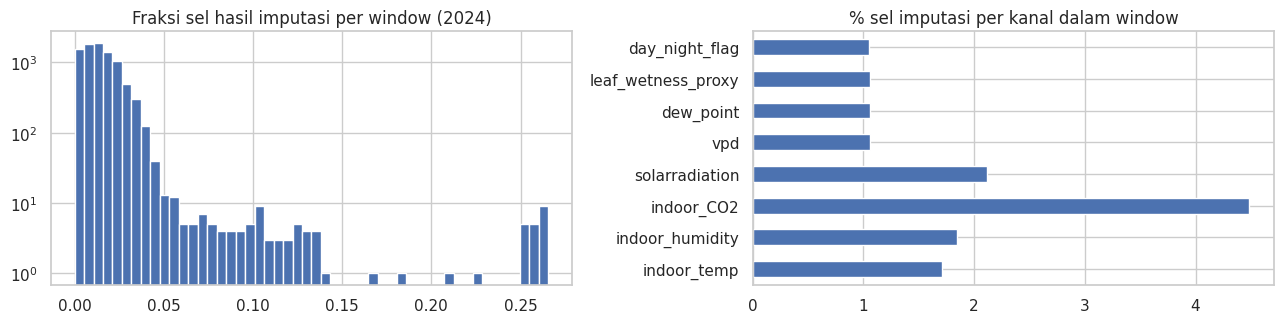

In [54]:
imp_win = np.lib.stride_tricks.sliding_window_view(IMP['2024'].to_numpy(np.float32), window_length_hours, axis=0)   # (n, F, W)
frac_imp = imp_win.mean(axis=(1, 2))
cat = pd.cut(frac_imp, bins=[-1e-9, 0, .05, .25, 1], labels=['0 % (tanpa imputasi)', '0 sampai 5 %', '5 sampai 25 %', '> 25 %'])
display(cat.value_counts().sort_index().to_frame('jumlah_window').assign(persen=lambda t: (100 * t.jumlah_window / len(frac_imp)).round(2)))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
ax[0].hist(frac_imp, bins=50); ax[0].set_yscale('log'); ax[0].set_title('Fraksi sel hasil imputasi per window (2024)')
pd.Series(imp_win.mean(axis=(0, 2)), index=FEATURES).mul(100).plot.barh(ax=ax[1], title='% sel imputasi per kanal dalam window')
plt.tight_layout(); plt.show()

## 7.3 Contoh window normal

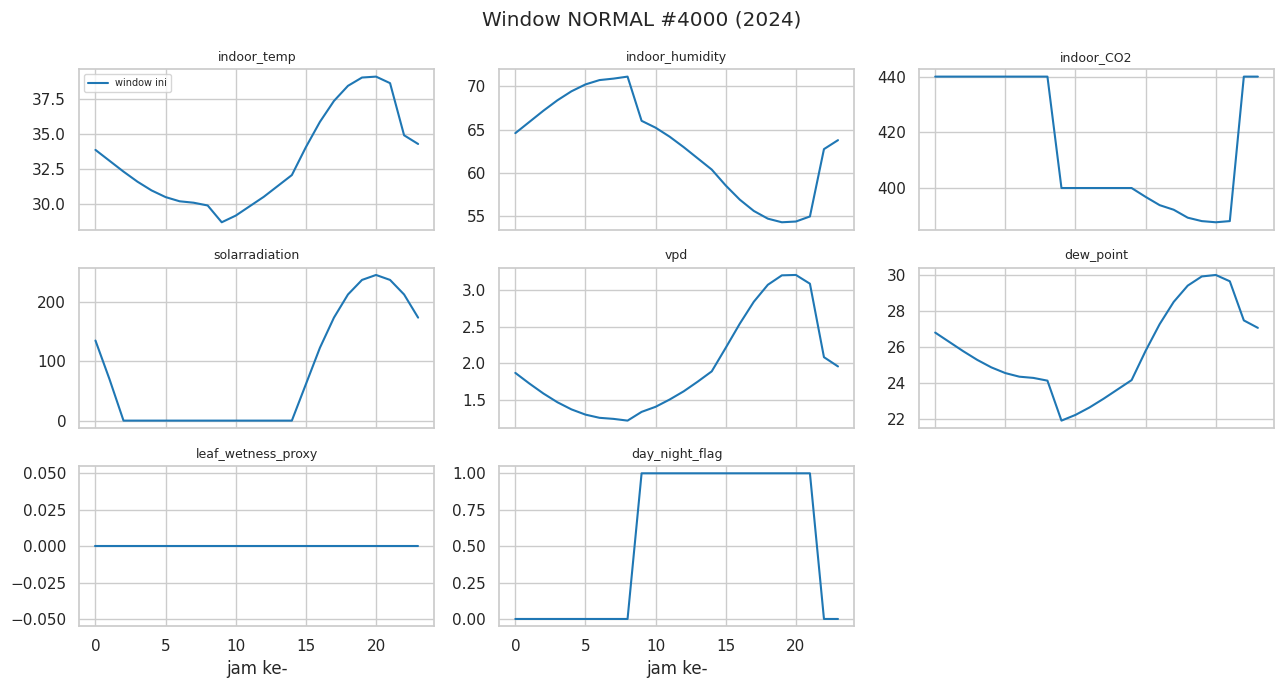

In [55]:
def plot_window(window, title='', mask=None, ref=None, ref_label='normal (asli)'):
    """Plot semua kanal sebuah window (T, F). mask (bool, T) menyorot jam anomali; ref = window pembanding."""
    fig, axes = plt.subplots(3, 3, figsize=(13, 7), sharex=True)
    for ax in axes.ravel()[N_FEATURES:]: ax.axis('off')
    hrs = np.arange(window.shape[0])
    for ax, name in zip(axes.ravel(), FEATURES):
        if ref is not None: ax.plot(hrs, ref[:, IX[name]], color='tab:blue', alpha=.6, label=ref_label)
        ax.plot(hrs, window[:, IX[name]], color='tab:red' if mask is not None else 'tab:blue', label='window ini')
        if mask is not None: ax.fill_between(hrs, *ax.get_ylim(), where=mask, color='orange', alpha=.25)
        ax.set_title(name, fontsize=9)
    for ax in axes[-1]: ax.set_xlabel('jam ke-')
    axes[0, 0].legend(fontsize=7); plt.suptitle(title); plt.tight_layout(); plt.show()

plot_window(w24[4000], 'Window NORMAL #4000 (2024)')

## 7.4 Injeksi anomali sintetis

Dataset tidak punya label anomali, jadi dibuat dengan memodifikasi salinan window normal (skala asli, sebelum scaling). Lima skenario:

| Skenario | Meniru | Cara |
|---|---|---|
| `temp_spike` | kegagalan ventilasi | suhu naik 8 sampai 14 C dalam 1 sampai 2 jam, bertahan 3 sampai 6 jam, `vpd` dan `dew_point` ikut dihitung ulang |
| `co2_extreme` | sensor gagal atau kebocoran gas | CO2 jatuh mendekati 0 ppm atau naik 1200 sampai 3000 ppm selama 3 sampai 8 jam |
| `humidity_saturated_day` | kondisi tidak wajar | RH menempel 100 % selama 5 sampai 10 jam pada siang hari |
| `stuck_sensor` | sensor macet | suhu, RH, atau radiasi konstan 8 sampai 14 jam, variabel turunan dibiarkan sehingga inkonsisten |
| `fungal_risk_day` | risiko jamur | siang hari RH 95 sampai 100 %, VPD mendekati 0, `leaf_wetness_proxy` = 1 selama 5 sampai 10 jam |

Siang didefinisikan dari `solarradiation > 1`, bukan dari `day_night_flag` (alasannya di 3.6).

In [56]:
def saturation_vp(t):
    return 0.6108 * np.exp(17.27 * t / (t + 237.3))                 # tekanan uap jenuh (kPa), Tetens

def compute_vpd(t, rh):
    return saturation_vp(t) * (1 - np.clip(rh, 0, 100) / 100)

def magnus_dew_point(t, rh):
    a, b = 17.62, 243.12
    g = np.log(np.clip(rh, 1, 100) / 100) + a * t / (b + t)
    return b * g / (a - g)

SCENARIOS = ['temp_spike', 'co2_extreme', 'humidity_saturated_day', 'stuck_sensor', 'fungal_risk_day']

def _longest_run(mask):
    """(start, end) rentang True berurutan terpanjang; (0, len) jika tidak ada."""
    best, s = (0, 0), None
    for i, m in enumerate(list(mask) + [False]):
        if m and s is None: s = i
        if (not m) and s is not None:
            if i - s > best[1] - best[0]: best = (s, i)
            s = None
    return best if best[1] - best[0] > 0 else (0, len(mask))

def _pick_period(rng, run, dmin, dmax):
    s, e = run
    dur = int(min(e - s, rng.integers(dmin, dmax + 1)))
    start = int(rng.integers(s, e - dur + 1))
    return start, start + dur

def _update_derived(w, m, t_old, rh_old):
    """Perbarui vpd dan dew_point pada langkah waktu m setelah suhu atau RH diubah."""
    t_new, rh_new = w[m, IX['indoor_temp']], w[m, IX['indoor_humidity']]
    w[m, IX['vpd']] = compute_vpd(t_new, rh_new)
    w[m, IX['dew_point']] = w[m, IX['dew_point']] + magnus_dew_point(t_new, rh_new) - magnus_dew_point(t_old, rh_old)

def _day_run(w):
    return _longest_run(w[:, IX['solarradiation']] > 1.0)

def _inj_temp_spike(w, rng):
    T = len(w); start = int(rng.integers(1, max(2, T - 5)))
    ramp, hold, delta = int(rng.integers(1, 3)), int(rng.integers(3, 7)), rng.uniform(8, 14)
    prof = np.zeros(T)
    for t in range(start, T):
        r = t - start
        prof[t] = (r + 1) / ramp if r < ramp else (1.0 if r < ramp + hold else max(0.0, 1 - (r - ramp - hold + 1) / 4))
    m = prof > 0
    t_old, rh_old = w[m, IX['indoor_temp']].copy(), w[m, IX['indoor_humidity']].copy()
    w[:, IX['indoor_temp']] += delta * prof
    _update_derived(w, m, t_old, rh_old)
    return m

def _inj_co2_extreme(w, rng):
    T = len(w); s, e = _pick_period(rng, (0, T), 3, 8)
    base = rng.uniform(1200, 3000) if rng.random() < 0.5 else rng.uniform(0, 150)
    w[s:e, IX['indoor_CO2']] = np.clip(base + rng.normal(0, 15, e - s), 0, None)
    m = np.zeros(T, bool); m[s:e] = True
    return m

def _inj_humidity_saturated_day(w, rng):
    T = len(w); s, e = _pick_period(rng, _day_run(w), 5, 10)
    m = np.zeros(T, bool); m[s:e] = True
    t_old, rh_old = w[m, IX['indoor_temp']].copy(), w[m, IX['indoor_humidity']].copy()
    w[m, IX['indoor_humidity']] = 100.0
    _update_derived(w, m, t_old, rh_old)
    return m

def _inj_stuck_sensor(w, rng):
    T = len(w); f = str(rng.choice(['indoor_temp', 'indoor_humidity', 'solarradiation']))
    dur = int(min(T, rng.integers(8, 15)))
    if f == 'solarradiation':        # macet di malam hari tidak terlihat, jadi mulai di jam siang
        s0, e0 = _day_run(w); start = int(rng.integers(s0, max(s0 + 1, e0 - 3)))
    else:
        start = int(rng.integers(0, T - dur + 1))
    e = min(T, start + dur)
    w[start:e, IX[f]] = w[start, IX[f]]
    m = np.zeros(T, bool); m[start:e] = True
    return m

def _inj_fungal_risk_day(w, rng):
    T = len(w); s, e = _pick_period(rng, _day_run(w), 5, 10)
    m = np.zeros(T, bool); m[s:e] = True
    t_old, rh_old = w[m, IX['indoor_temp']].copy(), w[m, IX['indoor_humidity']].copy()
    w[m, IX['indoor_humidity']] = rng.uniform(95, 100, m.sum())
    w[m, IX['leaf_wetness_proxy']] = 1.0
    _update_derived(w, m, t_old, rh_old)
    return m

_INJECTORS = {'temp_spike': _inj_temp_spike, 'co2_extreme': _inj_co2_extreme,
              'humidity_saturated_day': _inj_humidity_saturated_day,
              'stuck_sensor': _inj_stuck_sensor, 'fungal_risk_day': _inj_fungal_risk_day}

def inject_synthetic_anomalies(windows, scenarios=SCENARIOS, seed=0):
    """Salinan window normal (skala asli) + satu anomali per window, skenario dirotasi agar seimbang.
    Return: (windows_anomali, label_skenario, mask_anomali (n, T))."""
    rng = np.random.default_rng(seed)
    out = windows.copy()
    labels, masks = [], []
    for k in range(len(out)):
        sc = scenarios[k % len(scenarios)]
        masks.append(_INJECTORS[sc](out[k], rng)); labels.append(sc)
    return out, np.array(labels), np.array(masks)


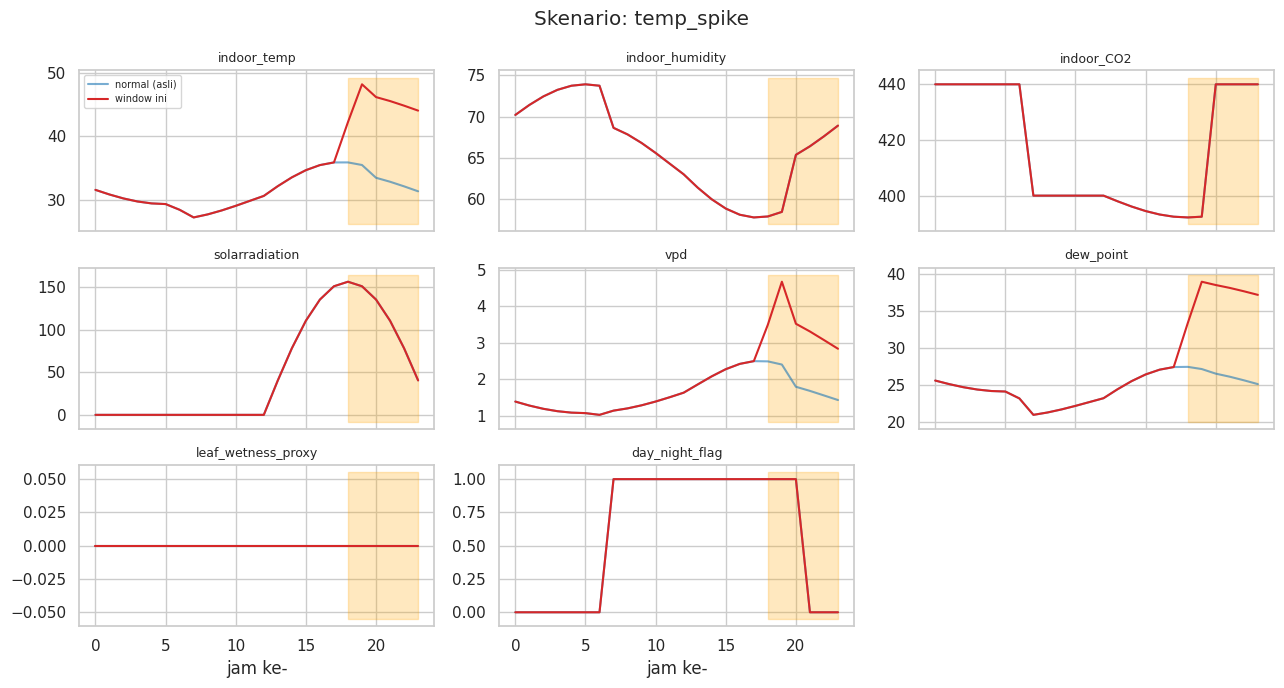

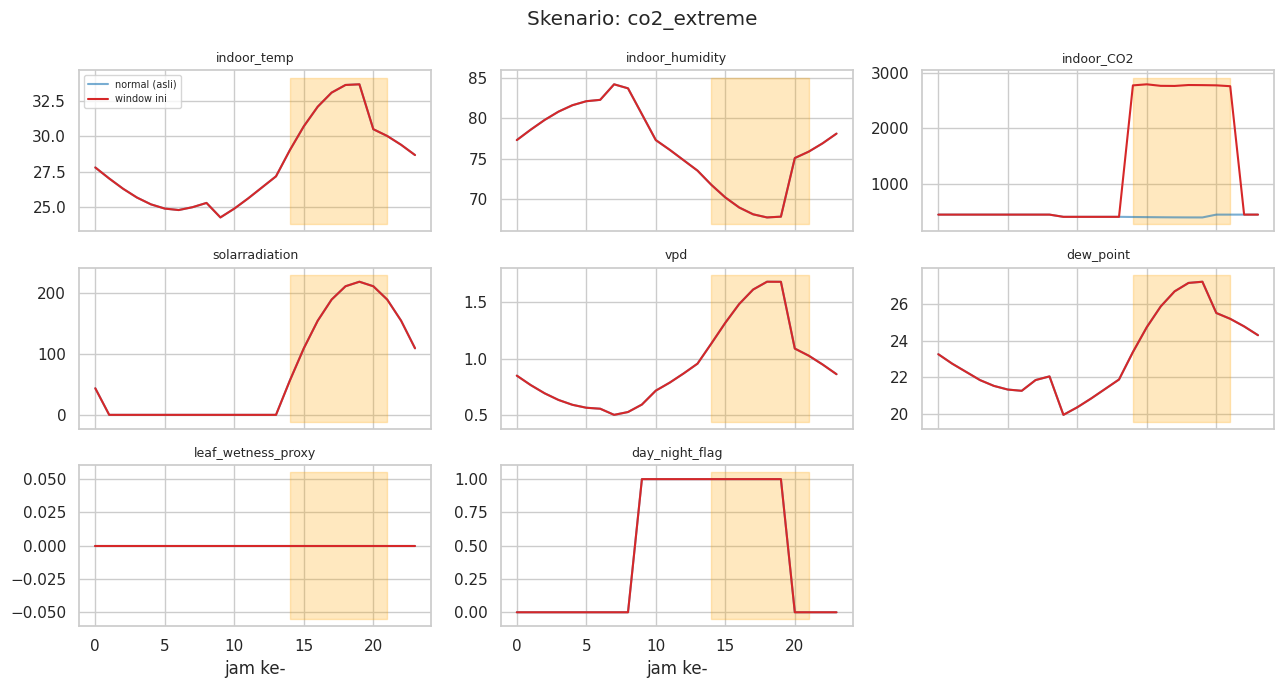

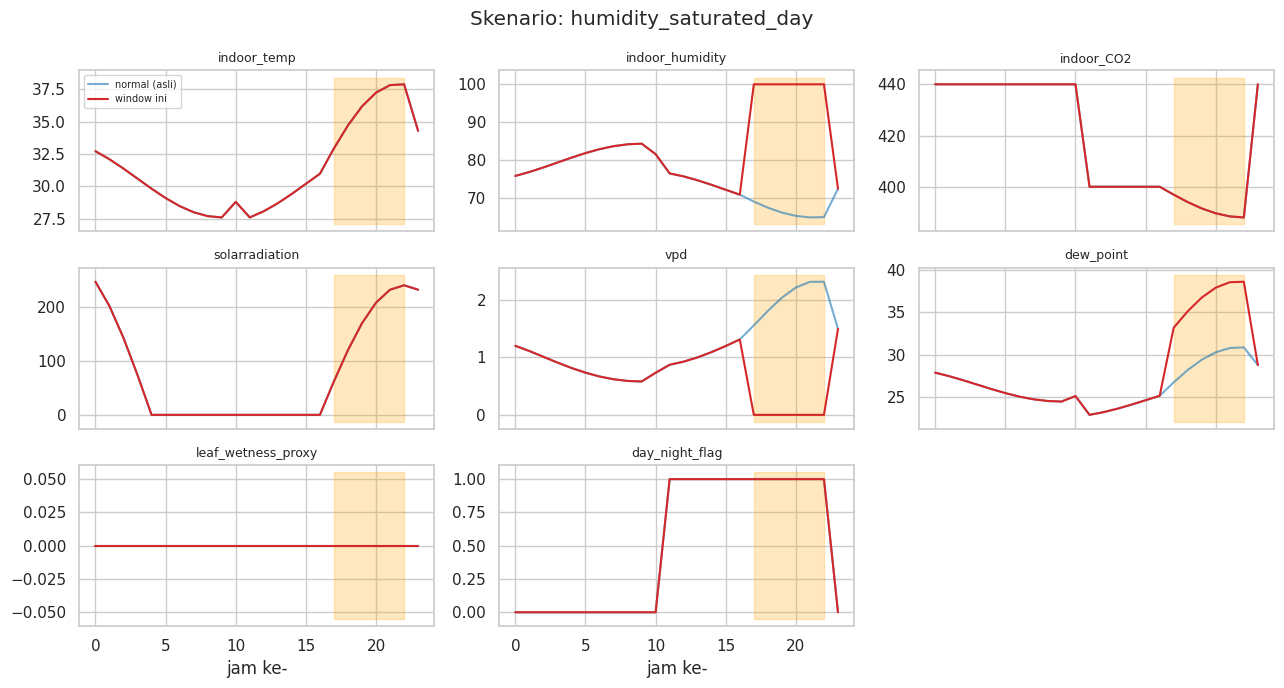

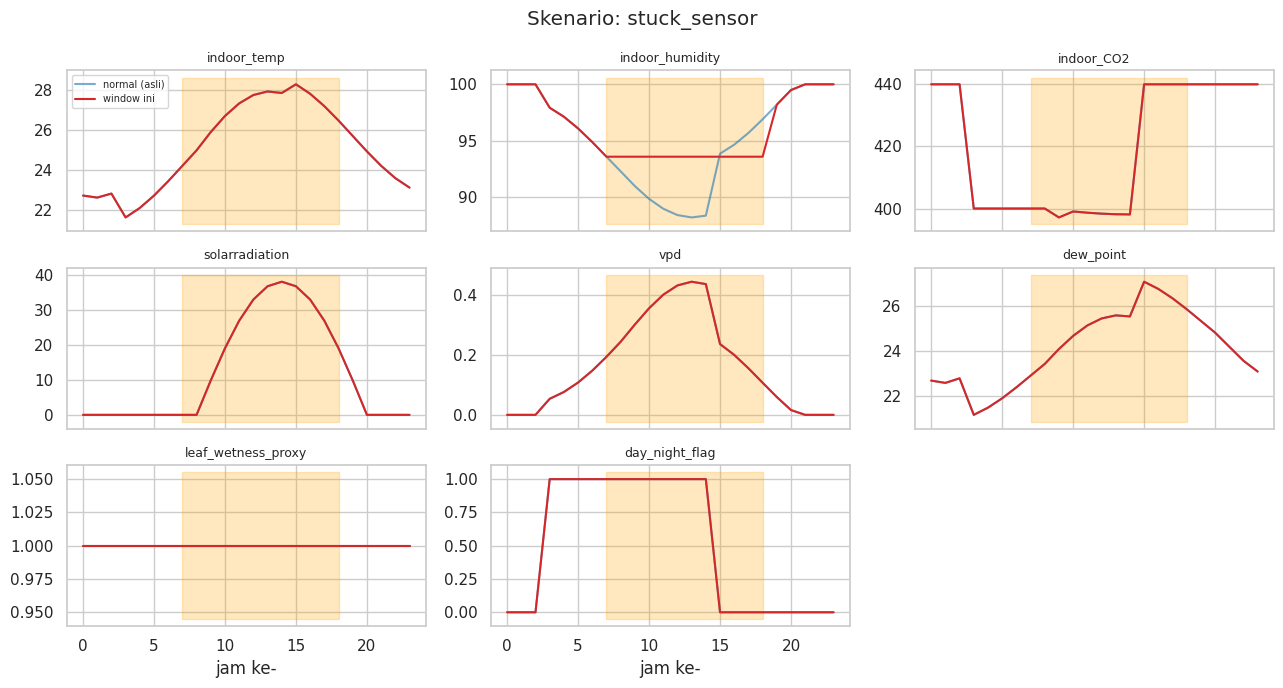

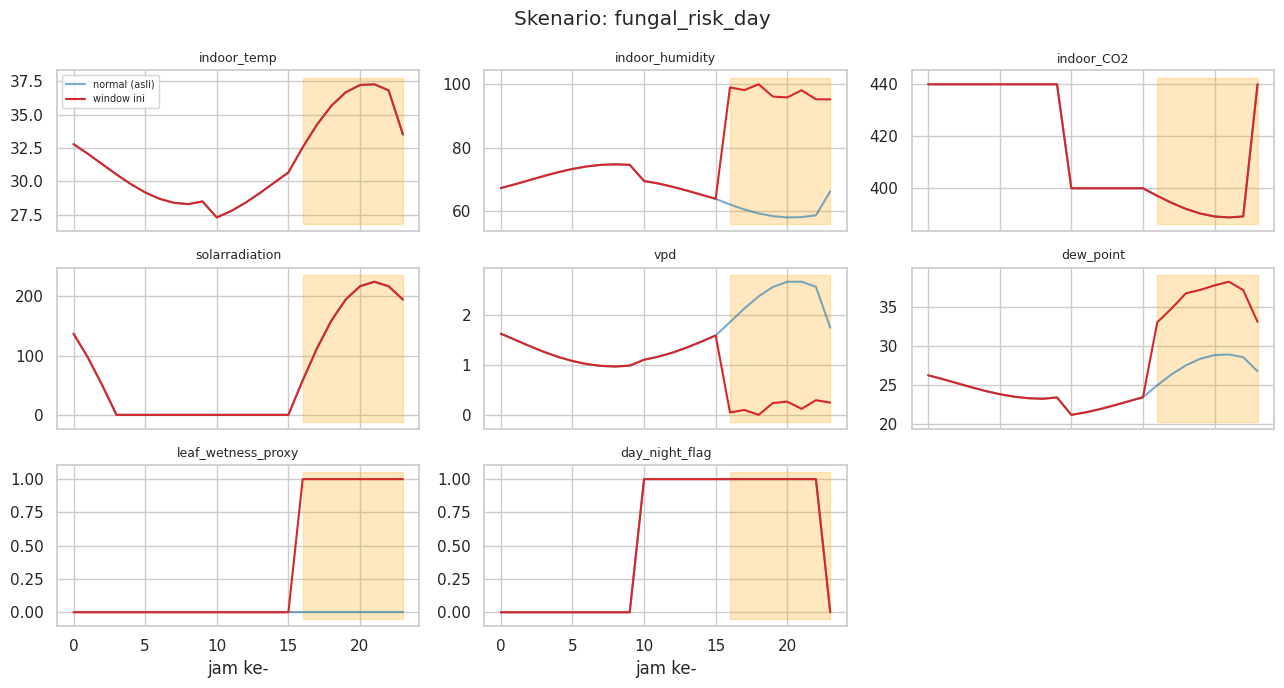

In [57]:
# Satu contoh per skenario: garis biru = window asli, merah = setelah injeksi, area oranye = jam anomali
rng = np.random.default_rng(1)
base_idx = rng.choice(len(w24), size=len(SCENARIOS), replace=False)
demo_anom, demo_lab, demo_mask = inject_synthetic_anomalies(w24[base_idx], seed=7)
for k in range(len(SCENARIOS)):
    plot_window(demo_anom[k], f'Skenario: {demo_lab[k]}', mask=demo_mask[k], ref=w24[base_idx[k]])

## 7.5 Set pembanding normal vs anomali

In [58]:
rng = np.random.default_rng(0)
perm = rng.permutation(len(w24))
w_norm = w24[perm[:1200]]
w_anom, lab_anom, mask_anom = inject_synthetic_anomalies(w24[perm[1200:2400]], seed=3)
print('Normal:', w_norm.shape, '| Anomali:', w_anom.shape)
print('Jumlah window per skenario:', pd.Series(lab_anom).value_counts().to_dict())
print('Rata-rata jam anomali per window:', mask_anom.sum(1).mean().round(2))

Normal: (1200, 24, 8) | Anomali: (1200, 24, 8)
Jumlah window per skenario: {'temp_spike': 240, 'co2_extreme': 240, 'humidity_saturated_day': 240, 'stuck_sensor': 240, 'fungal_risk_day': 240}
Rata-rata jam anomali per window: 7.83


Temuan: dari 1200 window anomali, tiap skenario 240 window dengan rata-rata 7,8 jam anomali per window. 93 % window 2024 punya kurang dari 5 % sel hasil imputasi dan hanya 14 window (0,16 %) yang lebih dari 25 %, jadi kualitas window baik.

## 7.6 Statistik satu window

In [59]:
STAT_CHANNELS = [f for f in FEATURES if f != 'day_night_flag']

def safe_corr(a, b):
    """Korelasi Pearson per baris (n, T). 0 jika salah satu sinyal konstan (mis. leaf_wetness selalu 0)."""
    a = a - a.mean(1, keepdims=True); b = b - b.mean(1, keepdims=True)
    den = np.sqrt((a ** 2).sum(1) * (b ** 2).sum(1))
    return np.where(den > 1e-9, (a * b).sum(1) / np.maximum(den, 1e-9), 0.0)

s = w_norm[0]
print('Bentuk window:', s.shape)
display(pd.DataFrame({'mean': s.mean(0), 'variance': s.var(0), 'MAD': stats.median_abs_deviation(s, axis=0),
                      'kurtosis': np.nan_to_num(stats.kurtosis(s, axis=0)), 'skew': np.nan_to_num(stats.skew(s, axis=0))},
                     index=FEATURES).round(3))
print('Korelasi antar kanal (NaN = salah satu sinyal konstan):')
display(pd.DataFrame(s, columns=FEATURES)[STAT_CHANNELS].corr().round(2))

Bentuk window: (24, 8)


,mean,variance,MAD,kurtosis,skew
indoor_temp,31.382000,9.167000,2.020,-1.026,0.626
indoor_humidity,72.862000,31.158001,5.401,-1.274,0.148
indoor_CO2,415.915009,502.489014,10.837,-1.898,0.097
solarradiation,69.786003,7284.976074,0.000,-1.263,0.660
vpd,1.295000,0.220000,0.270,-0.788,0.652
dew_point,25.965000,5.721000,1.748,-0.964,0.144
leaf_wetness_proxy,0.000000,0.000000,0.000,0.000,0.000
day_night_flag,0.542000,0.248000,0.000,-1.972,-0.167


Korelasi antar kanal (NaN = salah satu sinyal konstan):


,indoor_temp,indoor_humidity,indoor_CO2,solarradiation,vpd,dew_point,leaf_wetness_proxy
indoor_temp,1.00,-0.70,-0.49,0.95,0.93,0.94,NaN
indoor_humidity,-0.70,1.00,0.86,-0.62,-0.91,-0.43,NaN
indoor_CO2,-0.49,0.86,1.00,-0.37,-0.75,-0.22,NaN
solarradiation,0.95,-0.62,-0.37,1.00,0.85,0.92,NaN
vpd,0.93,-0.91,-0.75,0.85,1.00,0.76,NaN
dew_point,0.94,-0.43,-0.22,0.92,0.76,1.00,NaN
leaf_wetness_proxy,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7.7 Ekstraksi fitur statistik per window

Per kanal (kecuali `day_night_flag`): mean, variance, MAD, kurtosis, skew, ditambah dua fitur khusus deret waktu: `maxdiff` (lonjakan terbesar antar-jam) dan `flat` (fraksi langkah dengan perubahan 0, indikator sensor macet). Antar kanal: korelasi suhu-RH, VPD-leaf wetness, suhu-VPD.

In [60]:
def extract_features(windows):
    """windows: (n, T, F) skala asli -> DataFrame (n, n_fitur_statistik)."""
    feats = {}
    for f in STAT_CHANNELS:
        x = windows[:, :, IX[f]]
        feats[f'{f}_mean']    = x.mean(1)
        feats[f'{f}_var']     = x.var(1)
        feats[f'{f}_mad']     = stats.median_abs_deviation(x, axis=1)
        feats[f'{f}_kurt']    = np.nan_to_num(stats.kurtosis(x, axis=1))
        feats[f'{f}_skew']    = np.nan_to_num(stats.skew(x, axis=1))
        feats[f'{f}_maxdiff'] = np.abs(np.diff(x, axis=1)).max(1)
        feats[f'{f}_flat']    = (np.diff(x, axis=1) == 0).mean(1)
    g = lambda n: windows[:, :, IX[n]]
    feats['corr_temp_rh']  = safe_corr(g('indoor_temp'), g('indoor_humidity'))
    feats['corr_vpd_leaf'] = safe_corr(g('vpd'), g('leaf_wetness_proxy'))
    feats['corr_temp_vpd'] = safe_corr(g('indoor_temp'), g('vpd'))
    return pd.DataFrame(feats)

F_norm = extract_features(w_norm); F_norm['kondisi'] = 'Normal';  F_norm['skenario'] = 'normal'
F_anom = extract_features(w_anom); F_anom['kondisi'] = 'Anomali'; F_anom['skenario'] = lab_anom
F_all = pd.concat([F_norm, F_anom], ignore_index=True)
print('Jumlah fitur statistik:', F_all.shape[1] - 2)
display(F_all.groupby('kondisi')[['indoor_temp_mean', 'indoor_temp_var', 'indoor_CO2_mad', 'corr_temp_rh']].mean().round(3))

Jumlah fitur statistik: 52


,indoor_temp_mean,indoor_temp_var,indoor_CO2_mad,corr_temp_rh
kondisi,,,,
Anomali,31.211000,14.092,16.608999,-0.182
Normal,30.544001,9.482,13.392000,-0.825


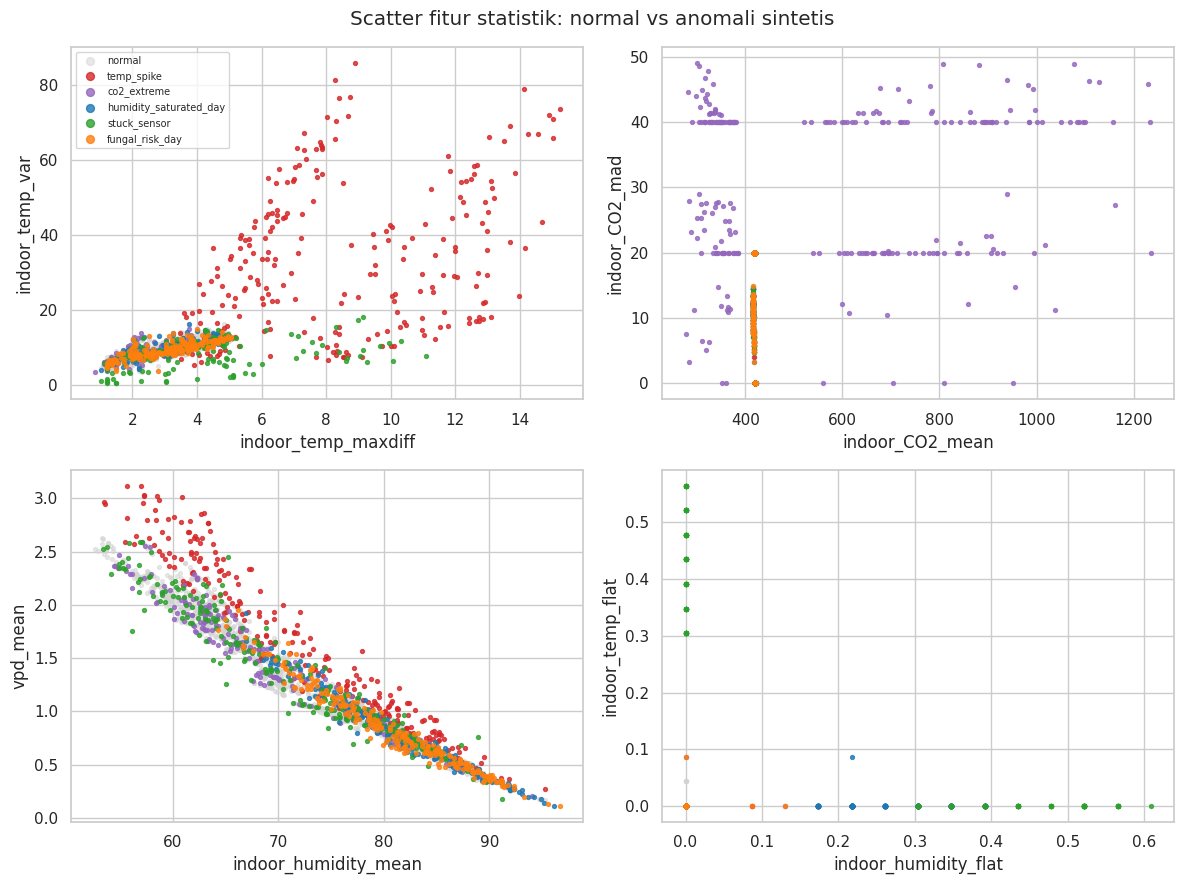

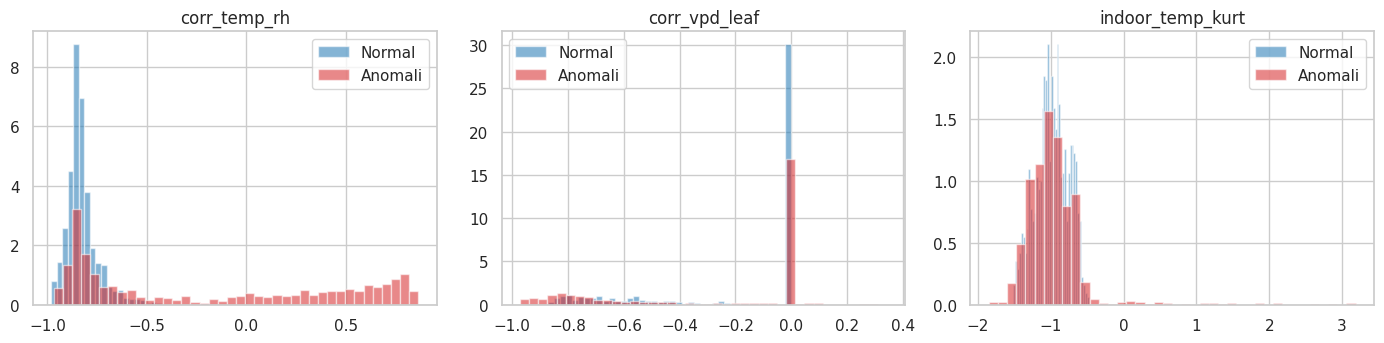

In [61]:
pairs = [('indoor_temp_maxdiff', 'indoor_temp_var'), ('indoor_CO2_mean', 'indoor_CO2_mad'),
         ('indoor_humidity_mean', 'vpd_mean'), ('indoor_humidity_flat', 'indoor_temp_flat')]
colors = {'normal': 'lightgray', 'temp_spike': 'tab:red', 'co2_extreme': 'tab:purple',
          'humidity_saturated_day': 'tab:blue', 'stuck_sensor': 'tab:green', 'fungal_risk_day': 'tab:orange'}
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (fx, fy) in zip(axes.ravel(), pairs):
    for sc, c in colors.items():
        d = F_all[F_all.skenario == sc]
        ax.scatter(d[fx], d[fy], s=8, alpha=.5 if sc == 'normal' else .8, color=c, label=sc)
    ax.set_xlabel(fx); ax.set_ylabel(fy)
axes[0, 0].legend(fontsize=7, markerscale=2); plt.suptitle('Scatter fitur statistik: normal vs anomali sintetis')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, c in zip(axes, ['corr_temp_rh', 'corr_vpd_leaf', 'indoor_temp_kurt']):
    for kond, col in [('Normal', 'tab:blue'), ('Anomali', 'tab:red')]:
        ax.hist(F_all.loc[F_all.kondisi == kond, c], bins=40, alpha=.55, color=col, label=kond, density=True)
    ax.set_title(c); ax.legend()
plt.tight_layout(); plt.show()

Temuan: `leaf_wetness_proxy` hampir selalu 0 (sekitar 90 % jam) sehingga pada banyak window variance dan MAD-nya 0 dan korelasinya diset 0. Rata-rata `corr_temp_rh` normal sekitar -0,83 dan turun menjadi sekitar -0,18 pada anomali, yaitu hubungan suhu dan RH yang rusak. `indoor_CO2_var` pada window normal sekitar 494 karena CO2 memang bertingkat, jadi lonjakan CO2 baru terlihat bila nilainya jauh di luar 384 sampai 440 ppm.

## 7.8 Fitur mana yang paling membedakan (ranking AUC)

ROC-AUC dipakai sebagai pemisah biner normal vs anomali, dibuat simetris `max(AUC, 1 - AUC)`. Nilai 0,5 tidak informatif, 1,0 sempurna. Ini hanya panduan intuisi: Autoencoder di Notebook 2 belajar langsung dari sinyal mentah, bukan dari fitur ini.

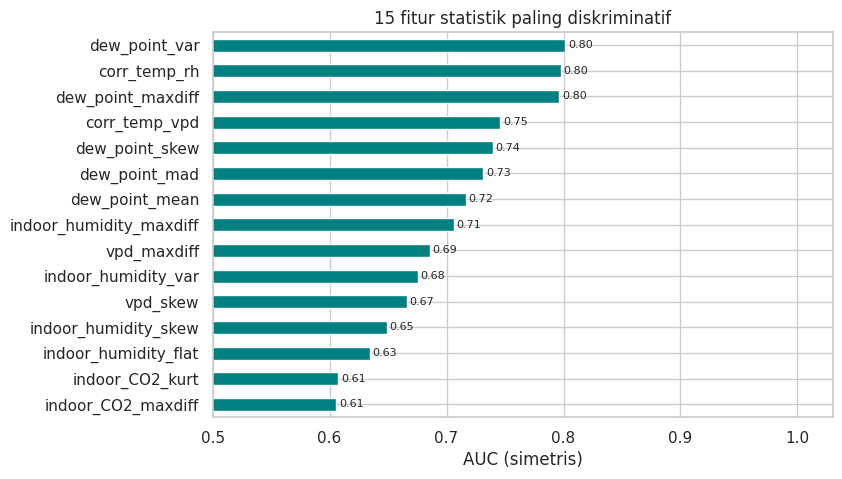

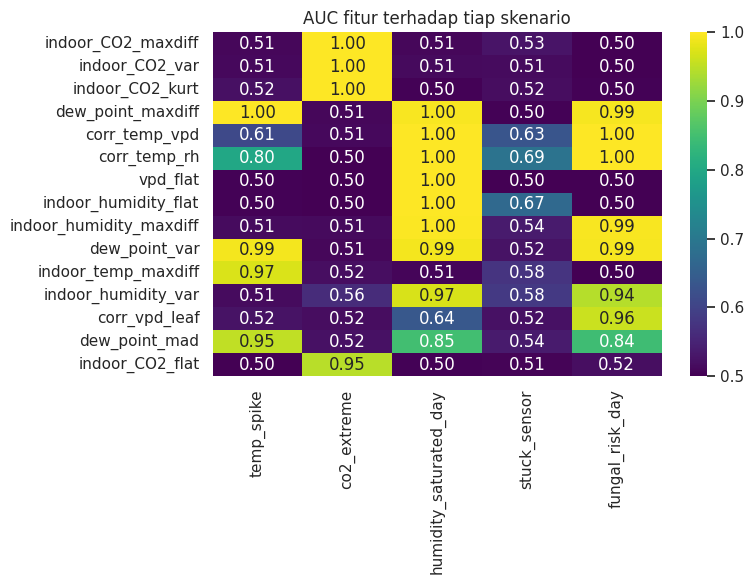

,fitur_terbaik,AUC
temp_spike,dew_point_maxdiff,1.000
co2_extreme,indoor_CO2_var,1.000
humidity_saturated_day,corr_temp_vpd,1.000
stuck_sensor,corr_temp_rh,0.691
fungal_risk_day,corr_temp_vpd,1.000


In [62]:
y = (F_all.kondisi == 'Anomali').astype(int).values
feat_cols = [c for c in F_all.columns if c not in ('kondisi', 'skenario')]
auc = pd.Series({c: roc_auc_score(y, F_all[c].values) for c in feat_cols})
auc = np.maximum(auc, 1 - auc).sort_values(ascending=False)
plt.figure(figsize=(8, 5)); ax = auc.head(15)[::-1].plot.barh(color='teal'); plt.xlim(.5, 1.03)
ax.bar_label(ax.containers[0], fmt='%.2f', fontsize=8, padding=2)
plt.xlabel('AUC (simetris)'); plt.title('15 fitur statistik paling diskriminatif'); plt.show()

# AUC tiap fitur untuk tiap skenario
A = {}
for sc in SCENARIOS:
    m = F_all.skenario.isin(['normal', sc]).values; ys = (F_all.skenario[m] == sc).astype(int)
    a = pd.Series({c: roc_auc_score(ys, F_all.loc[m, c]) for c in feat_cols}); A[sc] = np.maximum(a, 1 - a)
A = pd.DataFrame(A)
top = A.max(axis=1).sort_values(ascending=False).head(15).index
plt.figure(figsize=(8, 6)); sns.heatmap(A.loc[top], annot=True, fmt='.2f', cmap='viridis', vmin=.5, vmax=1)
plt.title('AUC fitur terhadap tiap skenario'); plt.tight_layout(); plt.show()
display(pd.DataFrame({'fitur_terbaik': A.idxmax(), 'AUC': A.max().round(3)}))

Temuan: fitur terbaik secara keseluruhan `dew_point_var` (AUC 0,80) dan `corr_temp_rh` (0,80). Per skenario, `temp_spike`, `co2_extreme`, `humidity_saturated_day`, dan `fungal_risk_day` bisa dipisah sempurna (AUC 1,0) oleh satu fitur tertentu, sedangkan `stuck_sensor` terbaik hanya 0,69. Sensor macet adalah kasus yang tidak tertangkap statistik sederhana dan butuh model yang melihat pola temporal dan antar-kanal.

## 7.9 PCA pada fitur statistik

Varians terjelaskan PC1, PC2: [0.188 0.177]


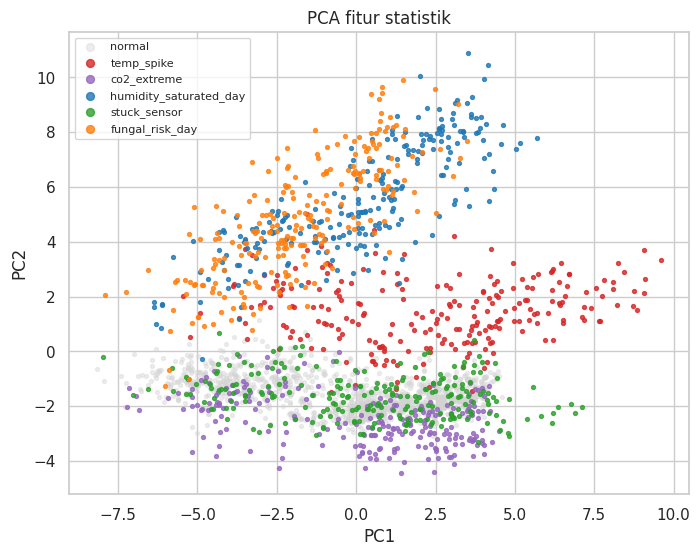

In [63]:
X = StandardScaler().fit_transform(F_all[feat_cols].values)
Z = PCA(n_components=2).fit(X)
P = Z.transform(X)
print('Varians terjelaskan PC1, PC2:', Z.explained_variance_ratio_.round(3))
plt.figure(figsize=(8, 6))
for sc, c in colors.items():
    m = (F_all.skenario == sc).values
    plt.scatter(P[m, 0], P[m, 1], s=8, alpha=.4 if sc == 'normal' else .8, color=c, label=sc)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(markerscale=2, fontsize=8); plt.title('PCA fitur statistik'); plt.show()

Temuan: dua komponen utama hanya menjelaskan sekitar 36 % varians (18,8 % dan 17,7 %) dan normal bercampur dengan anomali pada bidang 2D. Pemisahan yang baik tidak muncul dari dua dimensi saja, selaras dengan pemilihan Autoencoder yang melihat seluruh window.

## 7.10 Spektrum FFT per window

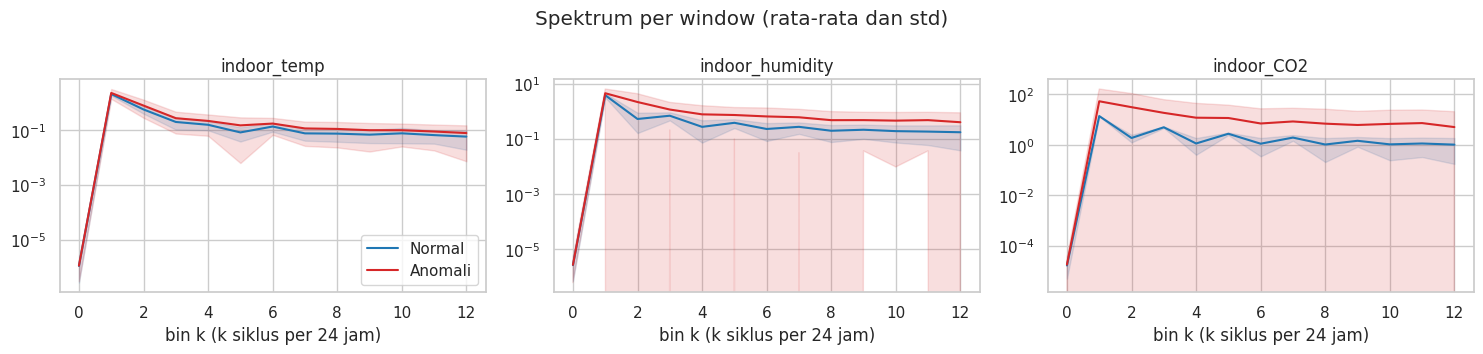

In [64]:
def window_spectrum(w, ch='indoor_temp'):
    x = w[:, :, IX[ch]]
    return np.abs(np.fft.rfft(x - x.mean(1, keepdims=True), axis=1)) / x.shape[1]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, ch in zip(axes, ['indoor_temp', 'indoor_humidity', 'indoor_CO2']):
    S_n, S_a = window_spectrum(w_norm, ch), window_spectrum(w_anom, ch)
    b = np.arange(S_n.shape[1])
    for S, c, l in [(S_n, 'tab:blue', 'Normal'), (S_a, 'tab:red', 'Anomali')]:
        ax.plot(b, S.mean(0), color=c, label=l); ax.fill_between(b, S.mean(0) - S.std(0), S.mean(0) + S.std(0), color=c, alpha=.15)
    ax.set_yscale('log'); ax.set_title(ch); ax.set_xlabel('bin k (k siklus per 24 jam)')
axes[0].legend(); plt.suptitle('Spektrum per window (rata-rata dan std)'); plt.tight_layout(); plt.show()

# TAHAP 8: Scaling, feature splitting, one-hot encoding, binning

## 8.1 Feature scaling

Fitur statistik punya satuan dan rentang berbeda (suhu sekitar 30, CO2 sekitar 400, variance 0 sampai puluhan). Aturan utama: `fit` scaler hanya pada data latih normal, lalu `transform` data lain, kalau tidak terjadi kebocoran data. Pipeline Notebook 2 memakai `StandardScaler` yang di-fit pada blok train 2024.

,mean,std,min,max
indoor_temp_mean,30.544,2.297,23.730,35.819
indoor_CO2_var,493.780,28.820,407.018,550.229
indoor_humidity_mad,4.652,1.091,0.736,9.807
indoor_temp_maxdiff,3.094,1.101,1.023,5.204


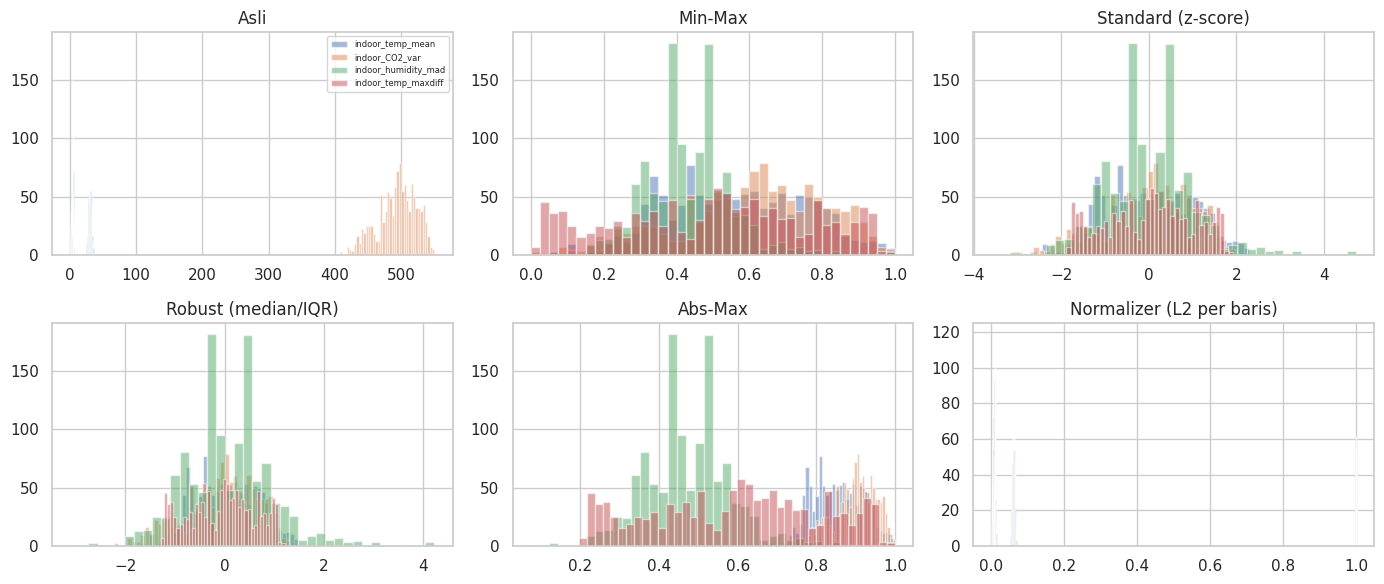

Rata-rata z-score fitur ANOMALI (skala normal):


,indoor_temp_mean,indoor_CO2_var,indoor_humidity_mad,indoor_temp_maxdiff
semua_anomali,0.29,1993.849976,0.61,1.07


,temp_spike,co2_extreme,humidity_saturated_day,stuck_sensor,fungal_risk_day
indoor_temp_mean,1.41,0.020000,0.01,0.03,-0.00
indoor_CO2_var,0.03,9969.169922,-0.02,0.06,0.01
indoor_humidity_mad,0.00,0.160000,2.09,-1.08,1.87
indoor_temp_maxdiff,4.84,-0.060000,-0.01,0.58,-0.00


In [65]:
demo_cols = ['indoor_temp_mean', 'indoor_CO2_var', 'indoor_humidity_mad', 'indoor_temp_maxdiff']
Xd = F_norm[demo_cols].copy()
display(Xd.describe().T[['mean', 'std', 'min', 'max']].round(3))

scalers = {'Asli': None, 'Min-Max': MinMaxScaler(), 'Standard (z-score)': StandardScaler(),
           'Robust (median/IQR)': RobustScaler(), 'Abs-Max': MaxAbsScaler(), 'Normalizer (L2 per baris)': Normalizer()}
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, (nm, sc) in zip(axes.ravel(), scalers.items()):
    data = Xd.values if sc is None else sc.fit_transform(Xd.values)
    for j, c in enumerate(demo_cols): ax.hist(data[:, j], bins=40, alpha=.5, label=c)
    ax.set_title(nm)
axes[0, 0].legend(fontsize=6); plt.tight_layout(); plt.show()

# fit di normal, transform di anomali: fitur anomali keluar dari rentang normal
sc = StandardScaler().fit(F_norm[demo_cols])
print('Rata-rata z-score fitur ANOMALI (skala normal):')
display(pd.DataFrame({'semua_anomali': sc.transform(F_anom[demo_cols]).mean(0)}, index=demo_cols).T.round(2))
display(pd.DataFrame({s: sc.transform(F_anom.loc[F_anom.skenario == s, demo_cols]).mean(0) for s in SCENARIOS}, index=demo_cols).round(2))

Temuan: pada anomali, z-score `indoor_CO2_var` untuk `co2_extreme` mencapai sekitar 9969 simpangan baku normal dan `indoor_temp_maxdiff` untuk `temp_spike` sekitar 4,8, jadi fitur sangat berskala besar bila tidak dinormalisasi. Karena `StandardScaler` dipakai di Notebook 2 dan di-fit hanya pada blok train 2024, skala ini konsisten antara latih dan evaluasi.

## 8.2 Fitur waktu dari `datetime`

Kolom waktu dipecah menjadi komponen jam, bulan, dan seterusnya, plus bentuk siklik jam (sin dan cos) supaya jam 23 dan jam 0 berdekatan. Ini hanya diuji hubungannya dengan sinyal siang, bukan ditambahkan ke model, karena window 24 jam sudah memuat urutan jam.

In [66]:
ts = df24.index.to_frame(index=False)
ts['tahun'] = ts['datetime'].dt.year
ts['bulan'] = ts['datetime'].dt.month
ts['hari'] = ts['datetime'].dt.day
ts['jam'] = ts['datetime'].dt.hour
ts['hari_minggu'] = ts['datetime'].dt.dayofweek
ts['hari_dalam_tahun'] = ts['datetime'].dt.dayofyear
ts['hour_sin'] = np.sin(2 * np.pi * ts['jam'] / 24)
ts['hour_cos'] = np.cos(2 * np.pi * ts['jam'] / 24)
display(ts.iloc[[0, 1, 6, 12, 18, 23]])

tmp = ts.join(df24.reset_index(drop=True)[['solarradiation', 'day_night_flag']])
print('Korelasi bentuk siklik jam dengan radiasi dan day_night_flag:')
display(tmp[['hour_sin', 'hour_cos', 'solarradiation', 'day_night_flag']].corr().loc[['hour_sin', 'hour_cos'], ['solarradiation', 'day_night_flag']].round(2))

,datetime,tahun,bulan,hari,jam,hari_minggu,hari_dalam_tahun,hour_sin,hour_cos
0,2024-01-01 00:00:00,2024,1,1,0,0,1,0.000000e+00,1.000000e+00
1,2024-01-01 01:00:00,2024,1,1,1,0,1,2.588190e-01,9.659258e-01
6,2024-01-01 06:00:00,2024,1,1,6,0,1,1.000000e+00,6.123234e-17
12,2024-01-01 12:00:00,2024,1,1,12,0,1,1.224647e-16,-1.000000e+00
18,2024-01-01 18:00:00,2024,1,1,18,0,1,-1.000000e+00,-1.836970e-16
23,2024-01-01 23:00:00,2024,1,1,23,0,1,-2.588190e-01,9.659258e-01


Korelasi bentuk siklik jam dengan radiasi dan day_night_flag:


,solarradiation,day_night_flag
hour_sin,0.00,0.88
hour_cos,-0.86,-0.18


## 8.3 One-hot encoding

Hanya label skenario anomali yang bersifat kategorikal (dipakai untuk evaluasi per skenario). Kolom sensor sudah numerik, `day_night_flag` dan `leaf_wetness_proxy` sudah biner 0/1 sehingga tidak perlu di-encode.

In [67]:
cat = pd.DataFrame({'day_night_flag': df24['day_night_flag'].iloc[:6].astype(int).astype(str).to_numpy(),
                    'skenario': ['normal', 'temp_spike', 'co2_extreme', 'stuck_sensor', 'fungal_risk_day', 'normal']})
enc = OneHotEncoder(sparse_output=False).fit(cat)
print('Kategori:', [list(c) for c in enc.categories_])
display(pd.concat([cat, pd.DataFrame(enc.transform(cat), columns=enc.get_feature_names_out())], axis=1))
print('Cara pandas, label skenario anomali:')
display(pd.get_dummies(F_all['skenario']).astype(int).iloc[[0, 1200, 1201, 1202, 1203, 1204]])

Kategori: [['0', '1'], ['co2_extreme', 'fungal_risk_day', 'normal', 'stuck_sensor', 'temp_spike']]


,day_night_flag,skenario,day_night_flag_0,day_night_flag_1,skenario_co2_extreme,skenario_fungal_risk_day,skenario_normal,skenario_stuck_sensor,skenario_temp_spike
0,0,normal,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,temp_spike,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1,co2_extreme,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,1,stuck_sensor,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1,fungal_risk_day,0.0,1.0,0.0,1.0,0.0,0.0,0.0
5,1,normal,0.0,1.0,0.0,0.0,1.0,0.0,0.0


Cara pandas, label skenario anomali:


,co2_extreme,fungal_risk_day,humidity_saturated_day,normal,stuck_sensor,temp_spike
0,0,0,0,1,0,0
1200,0,0,0,0,0,1
1201,1,0,0,0,0,0
1202,0,0,1,0,0,0
1203,0,0,0,0,1,0
1204,0,1,0,0,0,0


## 8.4 Binning durasi anomali

Durasi anomali dikelompokkan menjadi ringan, sedang, berat untuk membaca skenario mana yang cenderung lama. Binning ini hanya untuk analisis, bukan fitur model.

tingkat,ringan (<= 4 jam),sedang (5 sampai 8 jam),berat (> 8 jam)
skenario,,,
co2_extreme,77,163,0
fungal_risk_day,0,187,53
humidity_saturated_day,0,180,60
stuck_sensor,2,49,189
temp_spike,0,112,128


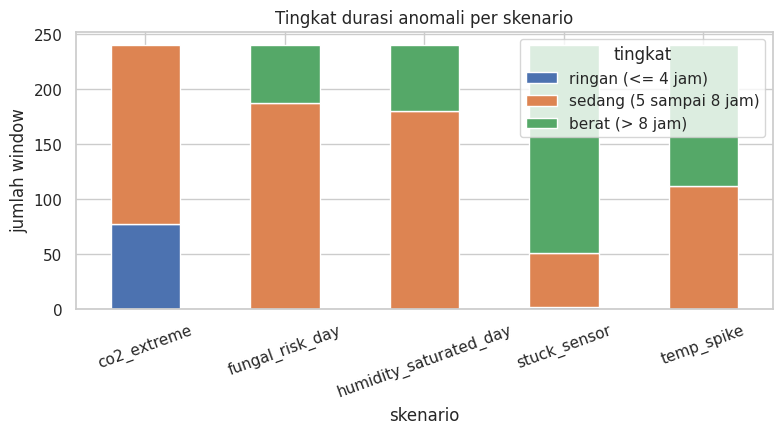

In [68]:
# (a) durasi anomali dan tingkat keparahan
durasi = mask_anom.sum(1)
bin_sev = pd.cut(durasi, bins=[0, 4, 8, 24], labels=['ringan (<= 4 jam)', 'sedang (5 sampai 8 jam)', 'berat (> 8 jam)'])
tab = pd.crosstab(pd.Series(lab_anom, name='skenario'), pd.Series(bin_sev, name='tingkat'))
display(tab)
tab.plot.bar(stacked=True, figsize=(9, 3.6)); plt.ylabel('jumlah window'); plt.title('Tingkat durasi anomali per skenario'); plt.xticks(rotation=20); plt.show()

# Cek akhir dan ringkasan keputusan

In [69]:
import json
assert list(df24.columns) == FEATURES and list(df25.columns) == FEATURES
assert w24.shape[1:] == (window_length_hours, N_FEATURES) and w25.shape[1:] == (window_length_hours, N_FEATURES)
assert not np.isnan(w24).any() and not np.isnan(w25).any() and not np.isnan(w_anom).any()
assert sum(len(v) for v in assign.values()) == len(blocks24)

fa_config = {
    'features': FEATURES, 'n_features': N_FEATURES,
    'dropped_missing': drop_cols, 'dropped_redundant': drop_redundant,
    'valid_range': {k: list(v) for k, v in VALID_RANGE.items()},
    'impute_policy': {k: list(v) for k, v in IMPUTE_POLICY.items() if k in FEATURES},
    'binary_columns': [c for c in BINARY if c in FEATURES],
    'vpd': 'dihitung ulang dari suhu dan RH (Tetens)',
    'day_definition': 'solarradiation > 1.0 (day_night_flag bergeser sekitar 7 jam dari matahari, tidak dipakai untuk siang)',
    'window_length_hours': window_length_hours, 'hop_hours': hop_hours,
    'block_hours': block_hours, 'val_ratio': val_ratio, 'test_ratio': test_ratio, 'seed': SEED,
    'block_assignment_2024': assign,
    'clean_files': {y: f'dindigul_greenhouse_indoor_{y}_clean.csv' for y in ('2024', '2025')},
    'n_rows': {'2024': len(df24), '2025': len(df25)},
}
with open(f'{CLEAN_DIR}/feature_analysis_config.json', 'w') as f:
    json.dump(fa_config, f, indent=2)

# Samakan dengan config model (Notebook 2) bila sudah ada
cfg_path = f'{models_path}/greenhouse_config.json'
if os.path.exists(cfg_path):
    model_feat = json.load(open(cfg_path))['features']
    if model_feat == FEATURES:
        print('FEATURES sama dengan greenhouse_config.json (urutan juga sama)')
    else:
        print('PERINGATAN: FEATURES tidak sama dengan greenhouse_config.json')
        print('  data bersih  :', FEATURES)
        print('  config model :', model_feat)
        print('  Model dan scaler di folder models/ belum cocok dengan data ini, jalankan ulang Notebook 2 lalu 3.')
else:
    print('greenhouse_config.json belum ada (Notebook 2 belum dijalankan)')
print('File di', CLEAN_DIR, ':', sorted(os.listdir(CLEAN_DIR)))


FEATURES sama dengan greenhouse_config.json (urutan juga sama)
File di /content/drive/MyDrive/greenhouse-anomaly-edgeai-main/datasets/clean : ['dindigul_greenhouse_indoor_2024_clean.csv', 'dindigul_greenhouse_indoor_2024_imputed_mask.csv', 'dindigul_greenhouse_indoor_2025_clean.csv', 'dindigul_greenhouse_indoor_2025_imputed_mask.csv', 'feature_analysis_config.json']
